In [1]:
import os
import glob
import numpy as np
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt 
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from scipy.ndimage import median_filter
from scipy.signal import find_peaks, peak_widths


### Básicos

In [2]:
# Espectro de SDSS
hdu_sdss= fits.open('sdss_specs/spec_cv_SDSSJ000130.5+050623.5.fits')
hdu_sdss.info()

Filename: sdss_specs/spec_cv_SDSSJ000130.5+050623.5.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     148   ()      
  1  COADD         1 BinTableHDU     26   4619R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPALL         1 BinTableHDU    488   1R x 236C   [27A, 14A, 4A, E, E, J, J, E, J, E, E, E, K, K, K, K, K, K, K, K, K, B, B, J, I, 5E, 5E, J, J, J, J, 7A, 7A, 16A, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, 5E, E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 16A, 9A, 12A, E, E, E, E, E, E, E, E, J, E, E, J, J, 6A, 21A, E, 35E, K, 19A, 19A, 19A, B, B, B, I, 3A, B, I, I, I, I, J, E, J, J, E, E, E, E, E, E, E, E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5J, 5J, 5J, 5E, 5J, 75E, 75E, 5E, 5E, 5E, 5J, 5E, D, D, D, D, D, D, D, D, D, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5

In [3]:
hdu_sdss

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x000001CBAF0BB620>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF0BB8C0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF0AF610>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CB8BA66E90>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF0A75C0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF0A7820>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF0B31D0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF04B130>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF04B350>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF093E50>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF248150>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF11D130>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF11D220>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001CBAF14C750>, <astropy.io.fits.hdu

In [4]:
hdu_sdss2= fits.open('sdss_specs/spec_cv_SDSSJ053553.6-004003.9.fits')
hdu_sdss2[4].header['TAIHMS']
hdu_sdss2[4].header['DATE-OBS']

'2005-02-14'

In [5]:
header_sdss=hdu_sdss[0].header
header_sdss

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
TELESCOP= 'SDSS 2.5-M'         / Sloan Digital Sky Survey                       
V_BOSS  = 'v4_0    '           / Active version of the BOSS ICC                 
FLAVOR  = 'science '           / exposure type, SDSS spectro style              
MJD     =                57367 / APO fMJD day at start of exposure              
MJDLIST = '57365 57367'        /                                                
V_GUIDER= 'v3_3    '           / version of the current guiderActor             
V_SOP   = 'v3_4    '           / version of the current sopActor                
NAME    = '8740-57364-01'      / The name of the currently loaded plate         
PLATEID =                 87

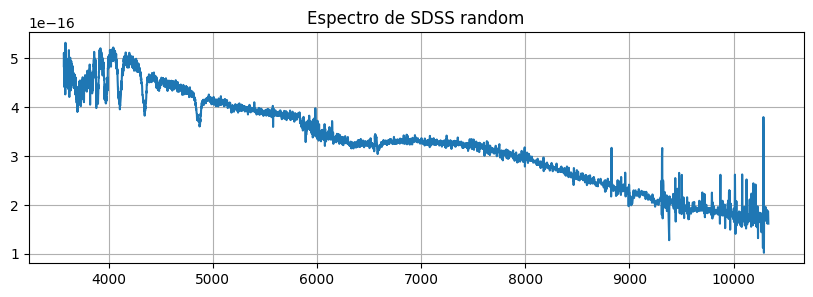

In [6]:
sdss= hdu_sdss[1].data
plt.figure(figsize=(10,3))
plt.plot((10**sdss['loglam']),sdss['flux']*1E-17)
plt.title('Espectro de SDSS random')
plt.grid('on')
plt.show()

In [7]:
#luego borrar
hdu= fits.open('CVs/qmost_14394762-0106068_1212603120741410670_LJ11_20260312.fits')
hdu[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
PRODCATG= 'SCIENCE.SPECTRUM'   / Data product category                          
ORIGIN  = 'ESO-PARANAL'        / Observatory or facility                        
TELESCOP= 'ESO-VISTA'          / ESO telescope designation                      
INSTRUME= 'QMOST   '           / Instrument name                                
TIMESYS = 'UTC     '           / Time system                                    
PROG_ID = '116.29EL.001'       / Observing run identification                   
OBSTECH = 'MOS     '           / Technique used during observation              
EQUINOX =               2000.0 / [yr] Epoch                                     
FLUXCAL = 'UNCALIBRATED'    

### Funciones para abrir los espectros

In [8]:
#definimos la funciones para leer los datos recortando los espectros hasta 9500 angstroms en base
# a las longitudes de onda en las que opera 4MOST para luego poder comparar 

def open_single_spectrum_SDSS(filename):
    """
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido.
    Retorna un diccionario con los datos.  Las variables se pueden extraer con las keys:

    "wavelength" "flux" "ivar" 
    "snr_global" "snr_g" "snr_b" 
    "exptime" "header": header_0.
    """
    try:
        with fits.open(filename) as hdu:
            dat = hdu['COADD'].data
            header = hdu[0].header
            date_obs= hdu[4].header['DATE-OBS']
            exptime= header['EXPTIME']
            
            # Extracción de variables
            flux = dat['flux']
            wavelength = 10**dat['loglam']
            ivar = dat['ivar']
            
            # sacamos el rayo cósmico molesto alrededor de 5579.6 y recortamos los espectros hasta 9500 angstroms            
            
            mask_valid = np.ones(len(flux), dtype=bool)
            mask_valid[(wavelength > 5576.6) & (wavelength < 5582.6)] = False
            mask_valid[wavelength > 9500.0] = False
            mask_valid[wavelength < 3700.0] = False    # estos recortes son facilmente editables

            clean_flux = flux[mask_valid]
            clean_wave = wavelength[mask_valid]
            clean_ivar = ivar[mask_valid] 
            
            
            
            bands = {
            'Blue':  (3700, 5400), 
            'Green': (5300, 7070),
            'Red':   (6900, 9500)}

            # Generamos las máscaras usando el eje limpio (clean_wave)
            idx_blue = (clean_wave >= bands['Blue'][0]) & (clean_wave <= bands['Blue'][1])
            idx_green = (clean_wave > bands['Green'][0]) & (clean_wave <= bands['Green'][1])
            idx_red = (clean_wave > bands['Red'][0]) & (clean_wave <= bands['Red'][1])
            
            # Calculamos el SNR aplicando las nuevas máscaras a los flujos e ivar limpios
            snr_blue = np.nanmedian(clean_flux[idx_blue] * np.sqrt(clean_ivar[idx_blue]))  # = flux/ (1/ivar)**0.5
            snr_green = np.nanmedian(clean_flux[idx_green] * np.sqrt(clean_ivar[idx_green]))
            snr_red = np.nanmedian(clean_flux[idx_red] * np.sqrt(clean_ivar[idx_red]))

            # Cálculo de ruido 
            good_pixels = clean_ivar > 0 
            noise = np.zeros_like(clean_ivar)
            noise[good_pixels] = np.sqrt(1 / clean_ivar[good_pixels])
            noise[~good_pixels] = np.nan
            
            snr_array= flux*np.sqrt(ivar)
            snr_global= np.nanmedian(snr_array)
            #signal_to_noise=  np.median(flux/noise)

            return {
                "filename": os.path.basename(filename),
                "wavelength": clean_wave,
                "flux": clean_flux,
                "ivar": clean_ivar,
                "snr_global": snr_global,
                "snr_r": snr_red,
                "snr_g": snr_green,
                "snr_b": snr_blue,
                "exptime": exptime,
                "header": header,
                "date_obs": date_obs
            }
            
    except Exception as e:
        print(f"Error procesando {filename}: {e}")
        return None
    
def load_all_spectra_sdss(folder_path):
    
    """
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido.
    Retorna un diccionario con los datos.
    Ejemplo de uso
    base_de_datos = load_all_spectra(carpeta_datos)
    y para acceder al primer espectro cargado:
    primer_espectro = base_de_datos[0]
    """
    search_pattern = os.path.join(folder_path, "*.fits") 
    
    #Lista con todos los archivos que coincidan con *.fits
    fits_files = glob.glob(search_pattern)
    
    print(f"Se encontraron {len(fits_files)} archivos espectrales.")
    
    spectra_database = []
    
    for file in fits_files:
        data = open_single_spectrum_SDSS(file)
        if data is not None:
            spectra_database.append(data)
            
    return spectra_database

In [9]:
spect=open_single_spectrum_SDSS('sdss_specs/spec_cv_SDSSJ000130.5+050623.5.fits')
spect['snr_global']

np.float32(63.41025)

In [10]:
def open_single_spectrum_4MOST(filename):
    """
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido SNR.
    Retorna un diccionario con los datos. Las variables se pueden extraer con las keys:

    "wavelength" "flux" "err" 
    "snr_global" "snr_g" "snr_b" 
    "exptime" "header": header_0.
    """
    try:
        with fits.open(filename) as hdu:
            dat = hdu[1].data
            header_0 = hdu[0].header
            header_1= hdu[1].header
            # Extracción de variables
            flux = dat['flux'][0]
            wavelength = dat['wave'][0]  
            err = dat['err'][0].astype(np.float64)  #para el nuevo formato    
            exptime= header_0['TEXPTIME']
            
            bands = {
            'Blue':  (3700, 5400), 
            'Green': (5300, 7070),
            'Red':   (6900, 9500)}

            
            #good_pixels= err> 8E-18
            #clean_err= err[good_pixels]
            #new_flux= flux[good_pixels]
            #clean_wave= wavelength[good_pixels]
            
            
                        # Generamos las máscaras usando el eje limpio (wavelength)
            idx_blue = (wavelength >= bands['Blue'][0]) & (wavelength <= bands['Blue'][1])
            idx_green = (wavelength > bands['Green'][0]) & (wavelength <= bands['Green'][1])
            idx_red = (wavelength > bands['Red'][0]) & (wavelength <= bands['Red'][1])
            
            
            # Calculamos el SNR aplicando las nuevas máscaras a los flujos e ivar limpios
            #MODIFICAR CON EL ERROR 
            #ivar= 1/(err**2)
            snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
            snr_green = np.nanmedian(flux[idx_green] / (err[idx_green]))
            snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
             
            # SNR global
            snr_array= flux/err
            snr_global= np.nanmedian(snr_array)


            #noise_norm = noise / np.median(flux)
            return {
                "filename": os.path.basename(filename),
                "wavelength": wavelength,
                "flux": flux,
                "err": err,
                "snr_global": snr_global,
                "snr_r": snr_red,
                "snr_g": snr_green,
                "snr_b": snr_blue,
                "exptime": exptime,
                "header": header_0
            }
            
    except Exception as e:
        print(f"Error procesando {filename}: {e}")
        return None
    
def load_all_spectra_4most(folder_path):
    
    """
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido.
    Retorna un diccionario con los datos.
    Ejemplo de uso
    base_de_datos = load_all_spectra(carpeta_datos)
    y para acceder al primer espectro cargado:
    primer_espectro = base_de_datos[0]
    """
    search_pattern = os.path.join(folder_path, "*.fits") 
    
    #Lista con todos los archivos que coincidan con *.fits
    fits_files = glob.glob(search_pattern)
    
    print(f"Se encontraron {len(fits_files)} archivos espectrales.")
    
    spectra_database = []
    
    for file in fits_files:
        data = open_single_spectrum_4MOST(file)
        if data is not None:
            spectra_database.append(data)
            
    return spectra_database

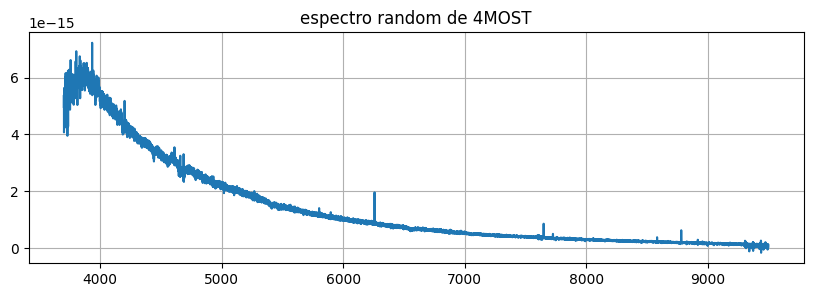

In [11]:
# lo abrimos par acorroborar que la función los abre bien 
spect_test_new= open_single_spectrum_4MOST("qmost_07221769-0621461_1312603050331411247_LJ11_20260305.fits")
plt.figure(figsize=(10,3))
plt.title('espectro random de 4MOST')
plt.plot(spect_test_new['wavelength'],spect_test_new['flux'])
plt.grid('on')
plt.show()

In [12]:
folder_4most= 'CVs2'
folder_sdss= 'sdss_specs'
db_4most= load_all_spectra_4most(folder_4most)
db_sdss= load_all_spectra_sdss(folder_sdss)
n= 0
spect_n_4most= db_4most[n]
spect_n_sdss= db_sdss[n]

Se encontraron 45 archivos espectrales.


C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:44: RuntimeWarning: invalid value encountered in divide
  snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:42: RuntimeWarning: invalid value encountered in divide
  snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:43: RuntimeWarning: invalid value encountered in divide
  snr_green = np.nanmedian(flux[idx_green] / (err[idx_green]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:42: RuntimeWarning: divide by zero encountered in divide
  snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:43: RuntimeWarning: divide by zero encountered in divide
  snr_green = np.nanmedia

Se encontraron 43 archivos espectrales.


In [13]:
n= 7
spect_n_4most= db_4most[n]
spect_n_sdss= db_sdss[n]
print(spect_n_4most['flux'].shape,spect_n_sdss['flux'].shape)

(23201,) (4090,)


In [14]:
print(spect_n_4most['exptime'])
print(spect_n_sdss['exptime'])

3600.0
5405.07


### Crossmatch

In [15]:
#Primero a mano
#para hacer el crossmatch desempaquetamos las coo como un par ordenado 
n= 0
spect_n_sdss= db_sdss[n]
sdss_header= spect_n_sdss['header']
most_header= spect_n_4most['header']

sdss_coo= [sdss_header["PLUG_RA"], sdss_header["PLUG_DEC"]]
most_coo= [most_header["RA"], most_header["DEC"]]

# la distancia angular la calculamos como sqrt([ra1-ra2)*cos dec1]^2-(dec1-dec2)^2) (angulos pequeños)
#RA y DEC ya vienen en ángulos, pero hay que pasar dec_sdss (dec1) a radianes para que np.cos funcione bien}
dec_1 = np.radians(sdss_coo[1])
dec_2= np.radians(most_coo[1])

ra_1= np.radians(sdss_coo[0])
ra_2= np.radians(most_coo[0])


#distancia= np.sqrt(((sdss_coo[0] - most_coo[0])*np.cos(dec_1))**2+(sdss_coo[-1] - most_coo[-1])**2 )
#la formula completa sin la aproximacion de angulos pequeños es:
distancia= np.degrees(np.arccos(np.sin(dec_1)*np.sin(dec_2)+ np.cos(dec_1)*np.cos(dec_2)*np.cos(ra_1-ra_2)))
treshold= 5/3600 #5 segundos de arco 

is_match= distancia < treshold
print(is_match) #todos False por ahora
print( distancia)

False
131.7426237468947


In [16]:
#Ahora si con skycoord
def cross_match(spect_4most, db_sdss, treshold=3): #ver si mejor integrar con residuals  (de todas formas luego mover arriba)
    """
    Dado el espectro de un objeto (spect_4most) calculamos la distancia angular 
    entre este objeto y los que tenemos en la base de datos de SDSS, si hay match me devuelve el espectro de SDSS
    con el que debemos calcular los residuals. Ejemplo de uso:
    cross_match(spect_n_4most, db_sdss, treshold=3)
    """
    most_header = spect_4most['header']
    
    # Creamos el objeto coordenado de astropy para 4MOST 
    coo_4most = SkyCoord(ra=most_header["RA"]*u.degree, 
                         dec=most_header["DEC"]*u.degree, 
                         frame='icrs')
    
    # Umbral de distancia en grados (con treshold dado en arcosegundos)
    treshold_deg = treshold / 3600.0
    
    #iteramos sobre nuestra base de datos de 43 objetos
    for spect_sdss in db_sdss:
        sdss_header = spect_sdss['header']
        
        coo_sdss = SkyCoord(ra=sdss_header["PLUG_RA"]*u.degree, 
                            dec=sdss_header["PLUG_DEC"]*u.degree, 
                            frame='icrs')
        
        # Usamos separation  para calcular la distancia
        distancia = coo_4most.separation(coo_sdss).degree
        #print(distancia) era sólo para corroborar con la formula como tal para chequear que use bien skycoord
        # Si la distancia es menor al umbral hay match
        if distancia < treshold_deg:
            print(f"Match encontrado a {distancia*3600:.2f} arcsec de distancia.")
            return spect_sdss #retornamos el espectro SDSS para los residuals
            
    # Si termina el ciclo y no encontró nada
    print(f"No se encontró match para el objeto en RA:{most_header['OBJ_RA']}")
    
spectro_match=cross_match(spect_n_4most, db_sdss, treshold=3)

Match encontrado a 0.15 arcsec de distancia.


### Interpolación

In [17]:
def interpolation(x_sdss,x_4most,y_4most,err_4most):  #convolucion para que el análisis sea mejor ? 
    
    f_interp= interp1d(x_4most, y_4most, kind='linear', bounds_error=False, fill_value=np.nan)
    flux_4most_resampled = f_interp(x_sdss)
    
    var_4most= err_4most**2
    v_interp= interp1d(x_4most,var_4most, kind='linear', bounds_error=False, fill_value=np.nan)
    var_resampled= v_interp(x_sdss)
    err_resampled= np.sqrt(var_resampled)
    
    return flux_4most_resampled, err_resampled

pares_procesados= []

for spect_n in db_4most:   #recorremos la carpeta de 4most
    spect_sdss_match= cross_match(spect_n,db_sdss)  #buscamos el espectro que le corresponde en sdss

    x_sdss= spect_sdss_match['wavelength']
    x_4most= spect_n['wavelength']
    y_4most= spect_n['flux']
    err_4most= spect_n['err']
    re_sampled_flux, re_sampled_err= interpolation(x_sdss,x_4most,y_4most,err_4most) #interpolamos el flujo de los espectros 
 
    spect_n['flux']= re_sampled_flux
    spect_n['wavelength']= spect_sdss_match['wavelength']
    spect_n['err']= re_sampled_err


Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 2.41 arcsec de distancia.
Match encontrado a 2.41 arcsec de distancia.
Match encontrado a 2.41 arcsec de distancia.
Match encontrado a 2.41 arcsec de distancia.
Match encontrado a 0.12 arcsec de distancia.
Match encontrado a 0.12 arcsec de distancia.
Match encontrado a 0.12 arcsec de distancia.
Match encontrado a 0.12 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match enco

In [18]:
## actualizamos la base de datos con los flujos interpolados #YA NO es necesario arriba lo hago en el mismo ciclo

#for i in range (len(db_4most)):
 #   db_4most[i]['flux'] = flujos_re_sampled[i]
  #  db_4most[i]['wavelength'] = db_sdss[i]['wavelength']
    

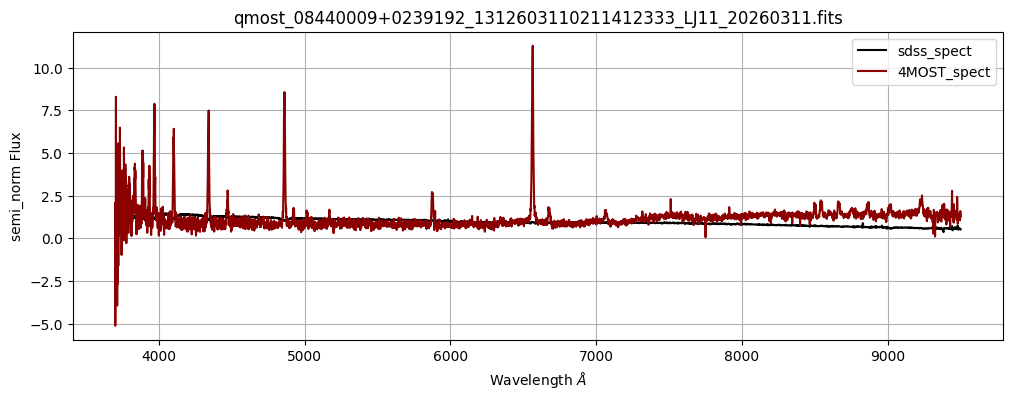

In [19]:
# visualizamos normalizando con la mediana para que tenga sentido

n=0
spect_n_4most= db_4most[n]
spect_n_sdss= db_sdss[n]

plt.figure(figsize=(12,4))
plt.title(spect_n_4most['filename'])
plt.plot(spect_n_sdss['wavelength'],spect_n_sdss['flux']/np.median(spect_n_sdss['flux']), color='black', label='sdss_spect')
plt.plot(spect_n_4most['wavelength'],spect_n_4most['flux']/np.median(spect_n_4most['flux']), color='darkred',label='4MOST_spect')
plt.xlabel(r'Wavelength $\AA$')
plt.ylabel(r'semi_norm Flux')
plt.legend()
plt.grid('on')
plt.show()


### Función para enmascarar

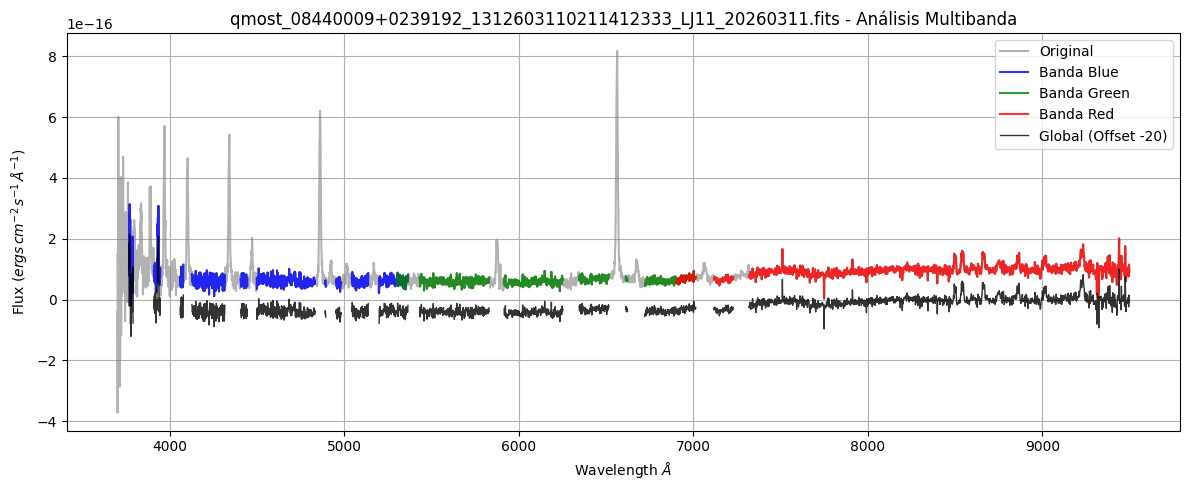

In [20]:
#ahora tratamos de enmascarar las lineas de los espectros de 4most
def mask_lines(espectro, sigma=4, plot=False):
    
    """
    Procesa el espectro en 3 bandas independientes (Blue, Green, Red) para 
    calcular estadísticas locales y enmascarar líneas de emisión y absorción.
    OUTPUTS:
    continuos_bandas, global_mask, found_lines_data
    """
    # Desempaquetar datos globales
    wavelength= espectro['wavelength']
    flux= espectro['flux']
    filename= espectro.get('filename', 'Espectro') # si no encuentra el filename nos devuelve sólo 'Espectro'
    #pseudo normalizamos el flujo para que sea más fácil todo
    #flux= flux/np.median(flux)
    
    # Diccionario con las bandas
    bands = {
    'Blue':  (3700, 5400), 
    'Green': (5300, 7070),
    'Red':   (6900, 9500)}
    
    # Diccionario con las líneas 
    lines = {
    # Serie de Balmer 
    'H_alpha': 6564.5377 * u.AA,  'H_beta': 4861.3615 * u.AA,   'H_gamma': 4340.462 * u.AA,
    'H_delta': 4101.74 * u.AA,    'H_epsilon': 3970.072 * u.AA, 'H_zeta': 3889.049 * u.AA,
    'H_eta': 3835.384 * u.AA,     'H_break': 3646.0 * u.AA,

    # He II 
    'HeII_a': 4686.992 * u.AA,    'HeII_b': 5413.024 * u.AA,  
    'HeII_d': 4542.863 * u.AA,    'HeII_f': 4201.014 * u.AA,
    'HeII_h': 4026.738 * u.AA,    'HeII_i': 1640.41 * u.AA,
    'HeII_j': 1215.13 * u.AA,     'HeII_k': 1085.12 * u.AA,     'HeII_l': 1025.44 * u.AA,

    # He I
    'HeI_a': 3706.054 * u.AA,     'HeI_b': 3733.921 * u.AA,     'HeI_c': 3820.694 * u.AA,
    'HeI_d': 3868.596 * u.AA,     'HeI_f': 3965.852 * u.AA,
    'HeI_g': 4010.404 * u.AA,     'HeI_h': 4025.107 * u.AA,     'HeI_i': 4027.338 * u.AA,
    'HeI_j': 4121.982 * u.AA,     'HeI_k': 4144.929 * u.AA,     'HeI_l': 4170.146 * u.AA,
    'HeI_m': 4389.163 * u.AA,     'HeI_n': 4438.795 * u.AA,     'HeI_o': 4472.755 * u.AA,
    'HeI_p': 4714.519 * u.AA,     'HeI_q': 4923.304 * u.AA,     'HeI_r': 5017.079 * u.AA,
    'HeI_s': 5049.147 * u.AA,     'HeI_t': 5877.329 * u.AA,     'HeI_u': 6679.994 * u.AA,
    'HeI_v': 7067.124 * u.AA,     'HeI_w': 7283.357 * u.AA,     'HeI_x': 3188.622 * u.AA,
    'HeI_y': 2945.961 * u.AA,
    
    #lineas que están pero aún no sé de que son
    '5175': 5175 * u.AA, '5578': 5578 * u.AA, '6310': 6310 * u.AA }    
    # #lineas telúricas 
    #'Sky_OH_7316': 7316.3 * u.AA, 'Sky_OH_7341': 7340.9 * u.AA,'Sky_OH_7369': 7369.3 * u.AA,
    #'Sky_OH_7821': 7821.5 * u.AA,'Sky_OH_7853': 7853.4 * u.AA,'Sky_OH_7914': 7913.7 * u.AA,
    #'Sky_OH_8344': 8344.6 * u.AA,'Sky_OH_8399': 8399.1 * u.AA,'Sky_OH_8430': 8430.2 * u.AA,
    #'Sky_OH_8827': 8827.1 * u.AA,'Sky_OH_8920': 8919.7 * u.AA,'Sky_OH_9318': 9318.0 * u.AA,
    #'Sky_OH_9376': 9376.0 * u.AA}
    
    #Comentar respecto a la resolución del espectro y las líneas muy cercanas entre sí (<1AA)
    # las que eliminé es pq chocan con H_zeta, H_delta, H_beta, H_gamma respectivamente
    #'HeI_e': 3889.752 * u.AA, 'HeII_g': 4101.197 * u.AA, 'HeII_c': 4860.677 * u.AA, 'HeII_e': 4339.89 * u.AA
    # Inicializamos máscara global (todo True al principio)
    
    global_mask = np.ones(len(wavelength), dtype=bool)
    
    # Estructuras para guardar resultados
    found_lines_data = []  # tuplas (Nombre, Lambda, FWHM)
    continuos_bandas = {} # Aquí guardaremos los 3 continuos separados
    
     # BUCLE PRINCIPAL POR BANDAS
    for band_name, (w_min, w_max) in bands.items():
        # 1 Recortamos el espectro para trabajar por bandas
        idx_band = (wavelength >= w_min) & (wavelength <= w_max)
        
        # Si la banda está vacía (por recorte del espectro), saltamos
        if np.sum(idx_band) == 0:
            continue

        wave_local = wavelength[idx_band]
        flux_local = flux[idx_band]
        
        # 2 Limpieza y cálculo de ruido LOCAL y SNR
        flux_clean = flux_local.astype(float)
        continuum_rough = median_filter(flux_clean, size=101)
        flattened = flux_local - continuum_rough
        flattened_inv = -flattened
        
        # usamos MAD porque es menos sensible al ruido (lo típico sería np.std --(ivar**-2)-- derechamente pero trae más ruido)
        mad = np.median(np.abs(flattened - np.median(flattened)))
        if mad == 0: mad = 1e-5        
        noise_level = mad * 1.4826
        
        # 3 Detección Automática (Find Peaks)
        # Usamos prominence basada en el ruido calculado
        peaks, properties = find_peaks(flattened, prominence=sigma*noise_level, width=2) 
        abs_peaks, abs_properties= find_peaks(flattened_inv, prominence= 5*noise_level, width=2)
        
        
        abs_widths,_,_,_ = peak_widths(flattened_inv, abs_peaks, rel_height=0.5,
                                            prominence_data=(abs_properties['prominences'], 
                                                            abs_properties['left_bases'], 
                                                            abs_properties['right_bases']))  #para absorción
        
        widths_fwhm, _, _, _ = peak_widths(flattened, peaks, rel_height=0.5,
                                            prominence_data=(properties['prominences'], 
                                                            properties['left_bases'], 
                                                            properties['right_bases']))   # para emisión 
        
        mask = np.ones(len(wavelength), dtype=bool)
        treshold_match = 12 

        found_lines_names_local = set()
        c_km_s = 299792.458  # velocidad de la luz en km/s
        if band_name == 'Blue':
            v_mask_limit= 800.0
        else:
            v_mask_limit = 1000.0 #  +- 1000 km/s alrededor de cada línea
        #enmascaramos las líneas de absorción
        for p_idx, w_px in zip(abs_peaks, abs_widths):
            if flattened[p_idx] > 0: continue # Si el pico en el espectro original apunta hacia arriba, lo ignoramos
            obs_w = wave_local[p_idx]    
                    
            # Dispersión local para pasar px -> Angstroms
            if p_idx < len(wave_local)-1:
                disp = wave_local[p_idx + 1] - wave_local[p_idx]
            else:
                disp = wave_local[p_idx] - wave_local[p_idx-1]
                    
            fwhm_abs_ang = w_px * disp
            fwhm_abs_vel=  c_km_s * (fwhm_abs_ang / obs_w)  

            #half_width_ang_abs = (fwhm_abs_vel * obs_w) / c_km_s
            half_width_ang_abs = (v_mask_limit * obs_w) / c_km_s
            found_match = False
            matched_name = ""
                    
            for name, line in lines.items():
                if abs(obs_w - line.value) < treshold_match:
                    found_match = True
                    matched_name = name
                    break

                
            if found_match:
            # Aplicamos la máscara global usando el ancho que calculamos arriba
                mask_width_abs= half_width_ang_abs *2.2 #para asegurarnos de incluir las alas
                #mask_width_abs= fwhm_abs_ang *2.5
                bad_region = (wavelength > obs_w - mask_width_abs) & (wavelength < obs_w + mask_width_abs)
                global_mask[bad_region] = False
                        
                found_lines_names_local.add(matched_name)   
                found_lines_data.append({
                    'name': matched_name, 
                    'wave': obs_w, 
                    'fwhm_ang': fwhm_abs_ang,
                    'type': 'absorption'
                        })
        
        #ahora las de emisión
        for peak_i, w_fwhm_px  in zip(peaks, widths_fwhm):
            obs_wave = wave_local[peak_i]
         
            # pasamos FWHM a velocidad usando la dispersión local para pasar de pixeles a angstroms
            if peak_i < len(wave_local)-1:
                dispersion = wave_local[peak_i + 1] - wave_local[peak_i]
            else:
                dispersion = wave_local[peak_i] - wave_local[peak_i-1]
            
            fwhm_ang = w_fwhm_px * dispersion
            fwhm_vel = c_km_s * (fwhm_ang / obs_wave)
            
            # calculamos el ancho de la máscara para la longitud de onda donde está la línea
            half_width_ang = (v_mask_limit * obs_wave) / c_km_s
            #half_width_ang = (fwhm_vel * obs_wave) / c_km_s
                
            found_match = False
            matched_name = ""
                
            for name, line in lines.items():
                if name in found_lines_names_local: continue
                if abs(obs_wave - line.value) < treshold_match:
                    found_match = True
                    matched_name = name
                    break

                
            if found_match:
                # Aplicamos la máscara global usando el ancho que calculamos arriba
                mask_width= half_width_ang*2.2 #para asegurarnos de incluir las alas
                #mask_width= fwhm_ang *2
                bad_region = (wavelength > obs_wave - mask_width) & (wavelength < obs_wave + mask_width)
                global_mask[bad_region] = False
                
                found_lines_names_local.add(matched_name)   
                found_lines_data.append({
                    'name': matched_name, 
                    'wave': obs_wave, 
                    'fwhm_ang': fwhm_ang,
                    'fwhm_vel': fwhm_vel, 
                    'type': 'emission'})

        # 4. Modo Rescate (Solo para líneas que caen en esta banda)
        rescued_count = 0
        for name, line_val in lines.items():
            
            # Si ya la encontramos seguimos de largo
            if name in found_lines_names_local: continue
            
            center_val = line_val.value
            
            # Solo intentamos rescatar si la línea pertenece a esta banda
            if not (w_min <= center_val <= w_max): continue
            
            # Ventana de búsqueda local
            window_mask = (wave_local > center_val - 15) & (wave_local < center_val + 15)
            
            if np.sum(window_mask) > 0:
                local_flux_window = flattened[window_mask]
                
                if len(local_flux_window) == 0: continue
                
                local_max_idx = np.argmax(local_flux_window)
                max_val = local_flux_window[local_max_idx]
                
                wave_window = wave_local[window_mask]
                peak_wave_rescue = wave_window[local_max_idx]
                
                # comprobamos si no está registrada y si es así enmascaramos
                ya_existe = any(abs(peak_wave_rescue - d['wave']) < 10.0 for d in found_lines_data)
                
                if not ya_existe and max_val > 2 * noise_level:

                    v_rescue = 1800.0 # km/s (un valor para cubrir alas)
                    rescue_width = (v_rescue * center_val) / c_km_s 
                    bad_region_rescue = (wavelength > peak_wave_rescue - rescue_width) & \
                                        (wavelength < peak_wave_rescue + rescue_width)
                    global_mask[bad_region_rescue] = False
                    
                    rescued_count += 1
                    found_lines_data.append({'name': name, 'wave': peak_wave_rescue, 'fwhm': np.nan, 'band': band_name, 'type': 'rescued'})

        # 5. Guardar el Continuo de esta Banda
        # Recortamos flux_local usando la máscara global (intersección con la banda)
        mask_local = global_mask[idx_band]
        
        # Guardamos tupla (Wavelength, Flux) limpios
        continuos_bandas[band_name] = (wave_local[mask_local], flux_local[mask_local])
        
       # print(f"  > {band_name}: Ruido={noise_level:.2f} | Líneas Auto={len(found_lines_names_local)} | Rescatadas={rescued_count}")


    # VISUALIZACIÓN
    if plot:
        #creamos el array maestro con huecos (NaNs)
        gaps_continuum = flux.copy()
        gaps_continuum[~global_mask] = np.nan 
        
        plt.figure(figsize=(12, 5))
        plt.title(f"{filename} - Análisis Multibanda")
        plt.plot(wavelength, flux, color='grey', alpha=0.6, label='Original')
        
        #  Continuos por banda con gaps
        colors = {'Blue': 'blue', 'Green': 'green', 'Red': 'red'}
        
        #  Iteramos sobre bands (los límites) para recortar el array con NaNs
        for b_name, (w_min, w_max) in bands.items():
            
            # Buscamos los índices de esta banda en el array global
            idx_band = (wavelength >= w_min) & (wavelength <= w_max)
            
            # Recortamos el array que tiene nans. 
            plt.plot(wavelength[idx_band], gaps_continuum[idx_band], 
                    color=colors[b_name], lw=1.5, alpha=0.8, label=f'Banda {b_name}')
            
        # graficamos el continuo global desplazado 
        plt.plot(wavelength, gaps_continuum-1E-16 , color='black', lw=1, alpha=0.8, label='Global (Offset -20)')

        plt.xlabel(r'Wavelength $\AA$')
        plt.ylabel(r'Flux ($ ergs\,cm^{-2}\,s^{-1}\,\AA^{-1}$)')
        plt.legend(loc='upper right')
        #plt.axvline(5175)
        #plt.axvline(5275)    #lineas presentes en el espectro [1] (en varios realmente)
        #plt.axvline(6564)
        plt.grid('on')
        plt.tight_layout()
        plt.show()
        
    return continuos_bandas, global_mask, found_lines_data # luego añadirS/N 
n= 0
spect_n_4most= db_4most[n]
spect_n_sdss= db_sdss[n]
continuos, mask, lines= mask_lines(spect_n_4most,plot=True)


#### Paneles

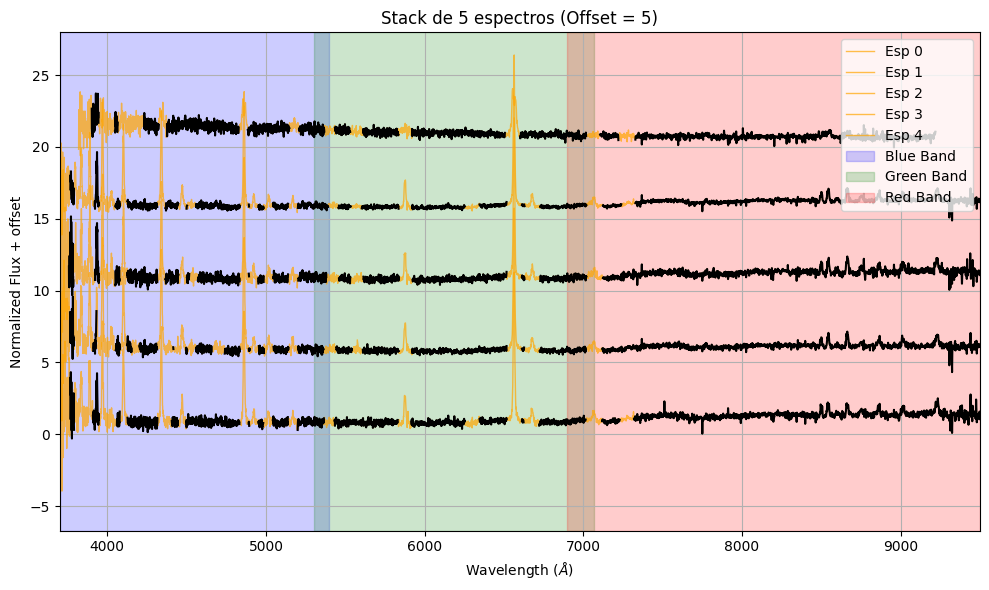

In [21]:
#ploteamos en un panel laa líneas enmascaradas
inicio = 0   # Desde qué espectro empezar
fin = 5      # Hasta cuál terminar 
offset_step = 5

# Seleccionamos el trozo de la base de datos que queremos
seleccion = db_4most[inicio:fin] 

plt.figure(figsize=(10, 6)) 
continuos=[]
mascaras=[]

# Iteramos sobre la selección usando enumerate
# i: índice relativo (0, 1, 2...) -> Sirve para el offset visual
# spect_n: el diccionario con los datos del espectro
for i, spect_n in enumerate(seleccion): 
    
    continuums, global_mask, lines = mask_lines(spect_n)
    mascaras.append(global_mask)
    #extraemos los datos para plotear
    x= spect_n['wavelength']
    y= spect_n['flux']/np.nanmedian(spect_n['flux'])
    
    #graficamos el continuo con gaps y añadimos el offset
    con_gaps= y.copy()
    con_gaps[~global_mask]= np.nan
    desplazamiento = i * offset_step
    y_desplazado= y+desplazamiento
    
    etiqueta = f"Esp {inicio + i}"
    plt.plot(x,y_desplazado, color= 'orange', alpha=0.7, lw=1, label=etiqueta)
    plt.plot(x,con_gaps+desplazamiento,color= 'black')
    
plt.axvspan(3700, 5400, color='blue', alpha=0.2, label='Blue Band')
plt.axvspan(5300, 7070, color='green', alpha=0.2, label='Green Band')
plt.axvspan(6900, 9500, color='red', alpha=0.2, label='Red Band')

plt.xlabel(r'Wavelength ($\AA$)')
#plt.ylabel(r'Flux ($10^{-17} erg \, s^{-1} \, cm^{-2} \, \AA^{-1}$) + Offset')
plt.ylabel('Normalized Flux + offset')
plt.title(f"Stack de 5 espectros (Offset = {offset_step})")
plt.legend(loc='upper right')
plt.xlim(3700,9500)
#plt.axvline(7283)   #una línea pequeña reconocerla requiere ajuste fino
#plt.axvline(5175)
#plt.axvline(3920)   #esta línea no está en el diccionario
plt.grid('on')
plt.tight_layout()
plt.show()

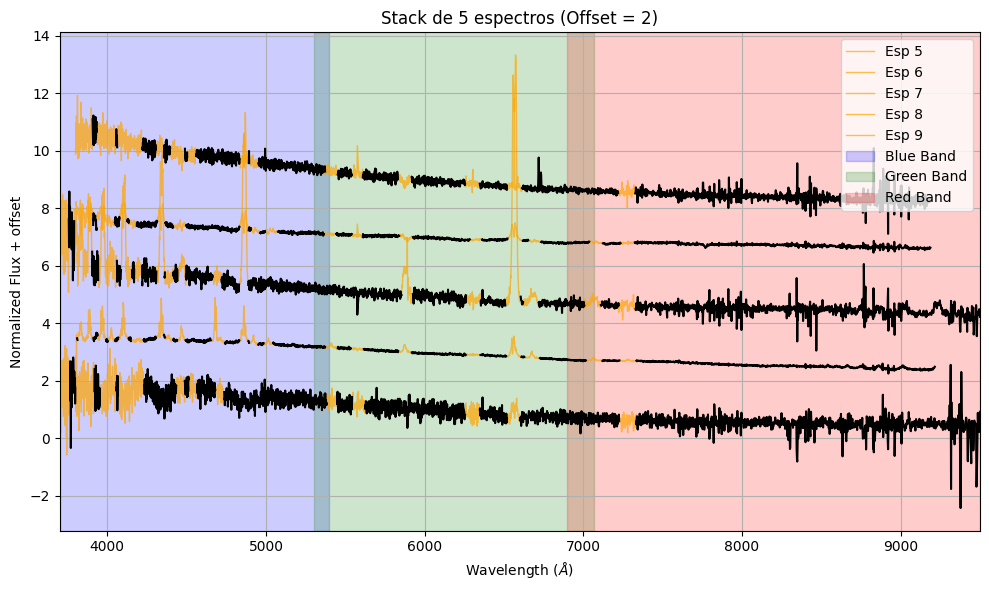

In [22]:
#ploteamos en un panel laa líneas enmascaradas
inicio = 5   # Desde qué espectro empezar
fin = 10      # Hasta cuál terminar 
offset_step = 2

# Seleccionamos el trozo de la base de datos que queremos
seleccion = db_sdss[inicio:fin] 

plt.figure(figsize=(10, 6)) 
continuos=[]
mascaras=[]

# Iteramos sobre la selección usando enumerate
# i: índice relativo (0, 1, 2...) -> Sirve para el offset visual
# spect_n: el diccionario con los datos del espectro
for i, spect_n in enumerate(seleccion): 
    
    continuums, global_mask, lines = mask_lines(spect_n)
    mascaras.append(global_mask)
    #extraemos los datos para plotear
    x= spect_n['wavelength']
    y= spect_n['flux']/np.nanmedian(spect_n['flux'])
    
    #graficamos el continuo con gaps y añadimos el offset
    con_gaps= y.copy()
    con_gaps[~global_mask]= np.nan
    desplazamiento = i * offset_step
    y_desplazado= y+desplazamiento
    
    etiqueta = f"Esp {inicio + i}"
    plt.plot(x,y_desplazado, color= 'orange', alpha=0.7, lw=1, label=etiqueta)
    plt.plot(x,con_gaps+desplazamiento,color= 'black')
    
plt.axvspan(3700, 5400, color='blue', alpha=0.2, label='Blue Band')
plt.axvspan(5300, 7070, color='green', alpha=0.2, label='Green Band')
plt.axvspan(6900, 9500, color='red', alpha=0.2, label='Red Band')

plt.xlabel(r'Wavelength ($\AA$)')
#plt.ylabel(r'Flux ($10^{-17} erg \, s^{-1} \, cm^{-2} \, \AA^{-1}$) + Offset')
plt.ylabel('Normalized Flux + offset')
plt.title(f"Stack de 5 espectros (Offset = {offset_step})")
plt.legend(loc='upper right')
plt.xlim(3700,9500)
#plt.axvline(7283)   #una línea pequeña reconocerla requiere ajuste fino
#plt.axvline(5175)
#plt.axvline(3920)   #esta línea no está en el diccionario
#plt.axvline(5578)
#plt.axvline(6310)
plt.grid('on')
plt.tight_layout() 
plt.show()

### Residuals


In [23]:
n= 0
spect_n_4most= db_4most[n]

matched_spectra= cross_match(spect_n_4most,db_sdss)

Match encontrado a 0.55 arcsec de distancia.


In [24]:
sdss_con, sdss_mask, sdss_lines= mask_lines(matched_spectra)
most_con, most_mask, most_lines= mask_lines(spect_n_4most)

In [25]:
matched_spectra['snr_r']

np.float32(21.134367)

In [26]:
sdss_con['Red'][1]
errors= np.std(sdss_con['Red'][1])
snr_blue_ms= np.nanmedian(sdss_con['Red'][1]/errors)
print(snr_blue_ms)

6.8789315


In [27]:
#print(matched_spectra['filename'])
a= fits.open('sdss_specs/spec_cv_SDSSJ084400.10+023919.3.fits')
a[0].header
#print(np.sqrt(38.3573)) # ahí se parece más 

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
TELESCOP= 'SDSS 2.5-M'         / Sloan Digital Sky Survey                       
V_BOSS  = 'v4_1_2  '           / Active version of the BOSS ICC                 
FLAVOR  = 'science '           / exposure type, SDSS spectro style              
MJD     =                58930 / APO fMJD day at start of exposure              
MJDLIST = '58930   '           /                                                
V_GUIDER= '3.8.1   '           / version of the current guiderActor             
V_SOP   = '3.12.7  '           / version of the current sopActor                
NAME    = '12527-58930-02'     / The name of the currently loaded plate         
PLATEID =                125

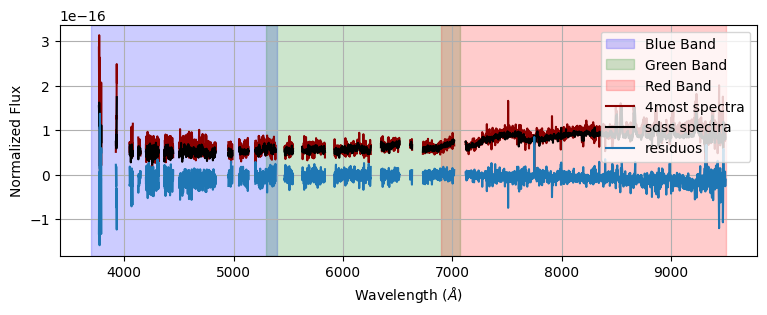

In [28]:
from matplotlib import gridspec

con_gaps_4most= spect_n_4most['flux'].copy()   #/np.median(spect_n_4most['flux'])
con_gaps_sdss= matched_spectra['flux'].copy()*1E-17    #/np.median(matched_spectra['flux'])

con_gaps_4most[~sdss_mask]=np.nan
con_gaps_sdss[~sdss_mask]=np.nan
a= spect_n_4most['flux']
b= spect_n_sdss['flux']
residuos= con_gaps_sdss - con_gaps_4most



plt.figure(figsize=(9,3))
plt.axvspan(3700, 5400, color='blue', alpha=0.2, label='Blue Band')
plt.axvspan(5300, 7070, color='green', alpha=0.2, label='Green Band')
plt.axvspan(6900, 9500, color='red', alpha=0.2, label='Red Band')

plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Normalized Flux')

plt.plot(spect_n_4most['wavelength'],con_gaps_4most, color='darkred', label= '4most spectra')   #en unidades de 1E-16
plt.plot(spect_n_4most['wavelength'],con_gaps_sdss, color='black', label= 'sdss spectra')        
plt.plot(spect_n_4most['wavelength'],residuos, label='residuos')
plt.legend()
plt.grid('on')

In [29]:
from highlight_text import ax_text
#%matplotlib qt5
def residuals(spect_n_sdss, spect_n_4most, plot=False):
    """
    Esta función nos devuelve los residuos entre el espectro 1 y el espectro 2 que le damos como input 
    Al primero se le resta el continuo del segundo, i.e., residuos = SDSS - 4MOST. Si usamos el parámetro plot= True podemos ver 
    un gráfico con los residuos y los continuos de cada espectro con las líneas enmascaradas.
    """
    
    #enmascaramos las líneas de ambos espectros 
    sdss_con, sdss_mask, sdss_lines= mask_lines(spect_n_sdss)
    most_con, most_mask, most_lines= mask_lines(spect_n_4most)
    
    #hacemos los continuos globales con las mascaras (con_gaps)
    con_gaps_4most= spect_n_4most['flux'].copy()   #/np.median(spect_n_4most['flux'])
    con_gaps_sdss= spect_n_sdss['flux'].copy()*1E-17     #/np.median(spect_n_sdss['flux'])

    con_gaps_4most[~sdss_mask]=np.nan
    con_gaps_sdss[~sdss_mask]=np.nan
    #Desempaquetamos los espectros originales y la metadata importante (exp_time y magnitudes)
    
    a= spect_n_4most['flux']           #/np.median(spect_n_4most['flux'])
    b= spect_n_sdss['flux']*1E-17            #/np.median(spect_n_sdss['flux'])
    
    header_sdss= spect_n_sdss['header']
    header_4most= spect_n_4most['header']
    
    #mags_4most= [header_4most['OBJ_BL'],header_4most['OBJ_GR'], header_4most['OBJ_RD']]
    #masg_sdss= [header_sdss[],header_sdss[],header_sdss[]]   TENGO PENSIENTE ENCONTRAR LAS MAGNITUDES DE SDSS 
    
    exptime_4most= spect_n_4most['exptime'] 
    exptime_sdss= spect_n_sdss['exptime']
    
    residuos= con_gaps_sdss - con_gaps_4most
    residuoos=  b[sdss_mask] - spect_n_4most['flux'][sdss_mask]
    #calculamos los snr
    snr_4most= [spect_n_4most['snr_r'],spect_n_4most['snr_g'],spect_n_4most['snr_b'],spect_n_4most['snr_global']]
    snr_sdss= [spect_n_sdss['snr_r'],spect_n_sdss['snr_g'],spect_n_sdss['snr_b'],spect_n_sdss['snr_global']]



    if plot:
        plt.figure(figsize=(14,5))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.09)
     
        # panel superior  (espectros)
        ax0 = plt.subplot(gs[0])

        
        ax0.axvspan(3700, 5400, color='blue', alpha=0.2)
        ax0.axvspan(5300, 7070, color='green', alpha=0.2)
        ax0.axvspan(6900, 9500, color='red', alpha=0.2)
        
        
        
        
        # hay que multitplicar el flujo de SDSS por *1E-17 porque viene asumiendo esas unidades
        ax0.plot(spect_n_4most['wavelength'], a, color='orange', alpha= 0.7)
        ax0.plot(spect_n_4most['wavelength'],b, color= 'darkslategrey', alpha= 0.7)
        ax0.plot(spect_n_4most['wavelength'], con_gaps_4most, color='darkred', lw=1, label='4MOST Resampled')
        ax0.plot(spect_n_4most['wavelength'], con_gaps_sdss, color='black', lw=1, alpha=0.8, label='SDSS Original')
        
        y_min, y_max = ax0.get_ylim()

        # Calculamos la posición en las coordenadas de los datos
        # para y usamos y_max bajando un 5% para que no choque con el borde superior

        y_pos = y_max - (y_max - y_min) * 0.05
        ax0.text(7050,y_pos*0.97,f'Snr global 4MOST {snr_4most[-1]:.2f}',color='darkred',fontsize=8)
        ax0.text(7050,y_pos*0.90,f'Snr global SDSS {snr_sdss[-1]:.2f}',fontsize=8)
        ax0.set_xlim(3700,9200)       
        ax0.set_ylabel((r'Flux [$10^{-17} ergs/(cm^2 s\,\AA)$]'))
        ax0.set_title(f"{spect_n_4most.get('filename', 'Objeto')}, EXPTIME: {spect_n_4most.get('exptime')}")
        ax0.legend(loc='upper right', fontsize='small')
        ax0.grid('on')

        # esto es para ocultar la etiqueta del eje X del panel superior para evitar solapamiento
        plt.setp(ax0.get_xticklabels(), visible=False)

        # panel inferior (residuos)
        ax1 = plt.subplot(gs[1], sharex=ax0) # Compartir el eje X es vital
        ax1.axvspan(3700, 5400, color='blue', alpha=0.2)
        ax1.axvspan(5300, 7070, color='green', alpha=0.2)
        ax1.axvspan(6900, 9500, color='red', alpha=0.2)
        
        ax1.plot(spect_n_4most['wavelength'], residuos, color='purple', label='Residuals (SDSS - 4MOST)')
        ax1.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea de referencia en cero
        
        ax1.axhline(1*1E-16,color='grey', linestyle='--') # Línea de referencia en 1 (si los residuos son del orden del ruido)
        
        ax1.set_xlabel(r'Wavelength ($\AA$)')
        ax1.set_ylabel('Flux Diff')
        ax1.grid('on')
        #ax1.set_ylim(-0.5, 0.5) # depende de la escala de los residuos 
        ax1.set_xlim(3700,9200)
        #plt.tight_layout()

        
        
        texto_snr = (
            f"Blue SNR: <{snr_4most[2]:.1f}> , <{snr_sdss[2]:.1f}> \n"
            f"Green SNR: <{snr_4most[1]:.1f}> , <{snr_sdss[1]:.1f}> \n"
            f"Red SNR: <{snr_4most[0]:.1f}> , <{snr_sdss[0]:.1f}> "
        )
        
        
        
        #TEXTO CON LA HORA DE OBSERVACIÓN 
        ax0.text(5450,y_pos*0.97,f'DATE_obs_4most={header_4most['DATE-OBS']}',color='darkred',fontsize=8)
        ax0.text(5450,y_pos*0.90,f'DATE_obs_sdss={spect_n_sdss['date_obs']}',color='black',fontsize=8)
        
        ax0.text(7050,y_pos*0.84,f'Exptime_sdss={exptime_sdss}',fontsize=8)
        #texto_mag= (f"Blue mag:<{mags_4most[0]:.1f}> \n"
        #            f"Green mag:<{mags_4most[1]:.1f}> \n"
        #            f"Red mag:<{mags_4most[2]:.1f}> " )
        
        #ax_text(7700,y_pos, texto_mag, transform=ax0.transAxes, 
        #        fontsize=8, ha='right', va='top',
        #        highlight_textprops=[
        #            {"color": "darkred"}, 
        #            {"color": "darkred"},
        #            {"color": "darkred"},
        #        ],
        #        ax=ax0)

        # ax_text inyecta el texto y colorea lo que está entre <>
        ax_text(8400, y_pos, texto_snr, transform=ax0.transAxes, 
                fontsize=8, ha='right', va='top',
                highlight_textprops=[
                    {"color": "darkred"}, {"color": "black"},
                    {"color": "darkred"}, {"color": "black"},
                    {"color": "darkred"}, {"color": "black"}
                ],
                ax=ax0)
        plt.show()
    
    return residuoos, sdss_mask, residuos

Match encontrado a 0.15 arcsec de distancia.


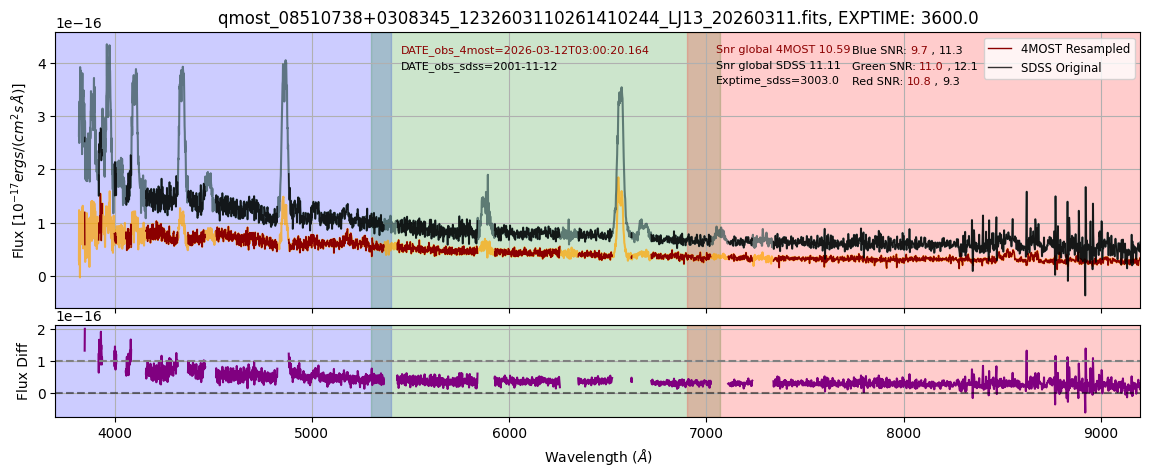

In [30]:
n= 7 #0,1,2,3 son un espectro al parecer 4,5,6,7 otro 8 y 9 son distintos
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

In [31]:
cross_match_2['filename']

'spec_cv_SDSSJ085107.38+030834.3.fits'

In [32]:
cross_match_2['filename']
hdu_sdss= fits.open('sdss_specs/spec_cv_SDSSJ084400.10+023919.3.fits')
hdu_sdss.info()



#print(hdu_sdss[4]['EXPTIME'])
print(hdu_sdss[5].header['EXPTIME'])
print(hdu_sdss[6].header['EXPTIME'])
print(hdu_sdss[7].header['EXPTIME'])
print(hdu_sdss[8].header['EXPTIME'])
print(hdu_sdss[9].header['EXPTIME'])
print(hdu_sdss[10].header['EXPTIME'])
print(hdu_sdss[11].header['EXPTIME'])
print(hdu_sdss[12].header['EXPTIME'])
print(hdu_sdss[13].header['EXPTIME'])


Filename: sdss_specs/spec_cv_SDSSJ084400.10+023919.3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     134   ()      
  1  COADD         1 BinTableHDU     26   4612R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPALL         1 BinTableHDU    488   1R x 236C   [27A, 14A, 4A, E, E, J, J, E, J, E, E, E, K, K, K, K, K, K, K, K, K, B, B, J, I, 5E, 5E, J, J, J, J, 7A, 7A, 16A, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, 5E, E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 16A, 9A, 12A, E, E, E, E, E, E, E, E, J, E, E, J, J, 6A, 21A, E, 35E, K, 19A, 19A, 19A, B, B, B, I, 3A, B, I, I, I, I, J, E, J, J, E, E, E, E, E, E, E, E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5J, 5J, 5J, 5E, 5J, 75E, 75E, 5E, 5E, 5E, 5J, 5E, D, D, D, D, D, D, D, D, D, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 

In [33]:
hdu_sdss[4].header['EXPTIME']

900.17

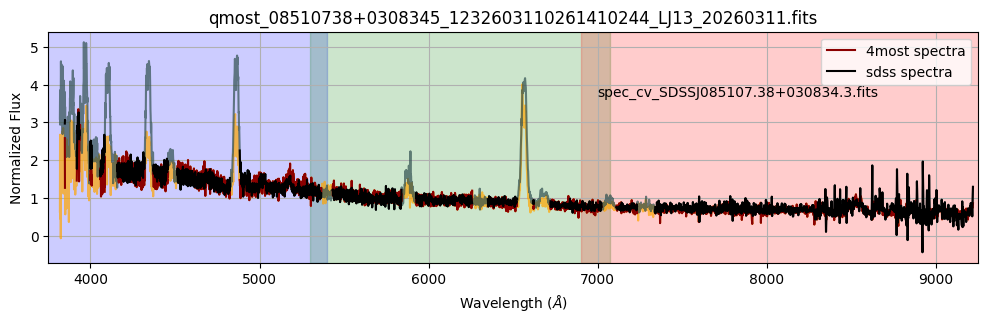

In [34]:
#probamos normalizar para jugar con el espectro
con_sdss, mask_sdss, lines_sdss= mask_lines(cross_match_2)
con_4most, mask_4most, lines_4most= mask_lines(spect_n_4most)

from matplotlib import gridspec

con_gaps_4most= spect_n_4most['flux'].copy()  /np.median(spect_n_4most['flux'])
con_gaps_sdss= cross_match_2['flux'].copy()   /np.median(cross_match_2['flux'])

con_gaps_4most[~mask_sdss]=np.nan
con_gaps_sdss[~mask_sdss]=np.nan
a= spect_n_4most['flux']                       /np.median(spect_n_4most['flux'])
b= cross_match_2['flux']                 /np.median(cross_match_2['flux'])

residuos= con_gaps_sdss - con_gaps_4most



plt.figure(figsize=(12,3))
plt.axvspan(3700, 5400, color='blue', alpha=0.2)
plt.axvspan(5300, 7070, color='green', alpha=0.2)
plt.axvspan(6900, 9500, color='red', alpha=0.2)

plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Normalized Flux')


plt.plot(spect_n_4most['wavelength'],a,color='orange', alpha= 0.7)
plt.plot(spect_n_4most['wavelength'],b,color='darkslategrey', alpha= 0.7)
plt.plot(spect_n_4most['wavelength'],con_gaps_4most, color='darkred', label= '4most spectra')   #en unidades de 1E-16
plt.plot(spect_n_4most['wavelength'],con_gaps_sdss, color='black', label= 'sdss spectra')      
plt.title(spect_n_4most['filename'])
plt.text(7000, 3.7,cross_match_2['filename'])  
#plt.plot(spect_n_4most['wavelength'],residuos, label='residuos')
plt.xlim(3750,9250)
plt.legend()
plt.grid('on')

In [35]:
print(spect_n_4most['filename'], cross_match_2['filename'])
print(cross_match_2['header']['PLUG_RA'],cross_match_2['header']['PLUG_DEC'])
print(spect_n_4most['header']['RA'],spect_n_4most['header']['DEC'])

qmost_08510738+0308345_1232603110261410244_LJ13_20260311.fits spec_cv_SDSSJ085107.38+030834.3.fits
132.78081 3.1428843
132.7807873854792 3.142917756468321


In [36]:
hdu_143947= fits.open('sdss_specs/spec_cv_SDSSJ143947.6-010606.8.fits')
head= hdu_143947[0].header
print(head['PLUG_RA'],head['PLUG_DEC'])

219.94844 -1.1018779


### Signal to noise

In [37]:
#S/N ratio SIN ENMASCARAR para sdss
#para calcular la S/N relation nececitamos los errores del flujo
#esto lo dejamos implementado en las funciones para abrir los espectros
import pandas as pd
n= 0
spect_n_4most= db_4most[n]
spect_n_sdss= db_sdss[n]
print( 'signal to noise para el espectro n de SDSS', spect_n_sdss['snr_global'], 'y para el espectro n de 4MOST:',spect_n_4most['snr_global'] )
# implementar por bandas?

datos=[]
for n in range(len(db_sdss)):
    spect_n_sdss= db_sdss[n]
    
    file= {'Filename': spect_n_sdss['filename'],
           'SNR_global': spect_n_sdss['snr_global'],
           'SNR_blue': spect_n_sdss['snr_b'],
           'SNR_green': spect_n_sdss['snr_g'],
           'SNR_red': spect_n_sdss['snr_r'] }

    datos.append(file)
    
df_snr_sdss= pd.DataFrame(datos)
subset_snr = df_snr_sdss[['SNR_blue', 'SNR_green', 'SNR_red']]

orden_excel= ['spec_cv_SDSSJ225831.18-094931.6.fits',
'spec_cv_SDSSJ204448.91-045928.8.fits',
'spec_cv_SDSSJ143947.6-010606.8.fits',
'spec_cv_SDSSJ040714.78-064425.1.fits',
'spec_cv_SDSSJ161007.50+035232.7.fits',
'spec_cv_SDSSJ001153.08-064739.2.fits',
'spec_cv_SDSSJ092009.54+004244.8.fits',
'spec_cv_SDSSJ223439.92+004127.2.fits',
'spec_cv_SDSSJ123813.73-033932.9.fits',
'spec_cv_SDSSJ144659.95+025330.3.fits',
'spec_cv_SDSSJ230351.64+010651.0.fits',
'spec_cv_SDSSJ121209.31+013627.7.fits',
'spec_cv_SDSSJ210014.11+004445.9.fits',
'spec_cv_SDSSJ113722.20+014858.7.fits',
'spec_cv_SDSSJ155644.23-000950.2.fits',
'spec_cv_SDSSJ204827.90+005008.9.fits',
'spec_SDSSV*_V388_Peg.fits',
'spec_cv_SDSSJ013701.06-091234.8.fits',
'spec_cv_SDSSJ143500.22-004606.3.fits',
'spec_cv_SDSSJ223843.83+010820.6.fits',
'spec_cv_SDSSJ084400.10+023919.3.fits',
'spec_cv_SDSSJ013132.38-090122.2.fits',
'spec_cv_SDSSJ085107.38+030834.3.fits',
'spec_cv_SDSSJ015543.39+002807.1.fits',
'spec_cv_SDSSJ151415.7+074446.7.fits',
'spec_cv_SDSSJ205914.87-061220.4.fits',
'spec_cv_SDSSJ161033.63-010223.2.fits',
'spec_cv_SDSSJ155531.98-001054.9.fits',
'spec_cv_SDSSJ232724.8+001943.fits',
'spec_cv_SDSSJ142256.31-022108.0.fits',
'spec_cv_SDSSJ090403.48+035501.2.fits',
'spec_cv_SDSSJ053553.6-004003.9.fits',
'spec_cv_SDSSJ124058.02-015919.2.fits',
'spec_cv_SDSSJ204817.84-061044.8.fits',
'spec_cv_SDSSJ004335.13-003729.8.fits',
'spec_cv_SDSSJ204720.76+000007.6.fits',
'spec_cv_SDSSJ163722.21-001957.1.fits',
'spec_cv_SDSSJ210449.94+010545.8.fits',
'spec_cv_SDSSJ023322.60+005059.5.fits',
'spec_SDSSCRTS_J112253.3-111037.fits',
'spec_cv_SDSSJ000130.5+050623.5.fits',
'spec_cv_SDSSJ014823.3-004807.7.fits',
'spec_cv_SDSSJ132411.57+032050.5.fits']

df_indexado = df_snr_sdss.set_index('Filename') #dejamos como indice el filename 
df_ordenado = df_indexado.reindex(orden_excel) #reordenamos con el indice que tenemos en el excel 
df_final = df_ordenado.reset_index() #devolvemos a los números de índice 

df_final
    


signal to noise para el espectro n de SDSS 63.41025 y para el espectro n de 4MOST: 8.123850521163682


,Filename,SNR_global,SNR_blue,SNR_green,SNR_red
0,spec_cv_SDSSJ225831.18-094931.6.fits,47.579384,46.139172,50.867748,46.743206
1,spec_cv_SDSSJ204448.91-045928.8.fits,38.170132,33.945236,44.704659,41.659676
2,spec_cv_SDSSJ143947.6-010606.8.fits,38.636471,39.195602,40.545700,33.352787
3,spec_cv_SDSSJ040714.78-064425.1.fits,36.848648,33.104874,41.433754,37.186443
4,spec_cv_SDSSJ161007.50+035232.7.fits,40.702969,35.676270,47.119984,44.741871
5,spec_cv_SDSSJ001153.08-064739.2.fits,46.903080,37.791748,58.315998,50.060707
6,spec_cv_SDSSJ092009.54+004244.8.fits,24.412655,22.153223,25.520863,27.003706
7,spec_cv_SDSSJ223439.92+004127.2.fits,18.896099,18.180029,21.308331,18.809095
8,spec_cv_SDSSJ123813.73-033932.9.fits,19.767895,21.306347,20.976343,13.073541
9,spec_cv_SDSSJ144659.95+025330.3.fits,19.520861,19.389954,21.400770,16.895803


In [38]:
#S/N ratio para los continuos ENMASCARADOS sdss

bands = {
'Blue':  (3700, 5400), 
'Green': (5300, 7070),
'Red':   (6900, 9500)}


for spect_n in (db_sdss):
    sdss_con, sdss_mask, sdss_lines= mask_lines(spect_n)
    
    # Generamos las máscaras 
    idx_blue = (spect_n['wavelength'] >= bands['Blue'][0]) & (spect_n['wavelength'] <= bands['Blue'][1])
    idx_green = (spect_n['wavelength'] > bands['Green'][0]) & (spect_n['wavelength'] <= bands['Green'][1])
    idx_red = (spect_n['wavelength'] > bands['Red'][0]) & (spect_n['wavelength'] <= bands['Red'][1])
    
    mask_b= idx_blue & sdss_mask
    mask_g= idx_green & sdss_mask
    mask_r= idx_red & sdss_mask
    
    
    spect_n['snr_b'] = np.nanmedian(spect_n['flux'][mask_b] * np.sqrt(spect_n['ivar'][mask_b]))
    spect_n['snr_g']=   np.nanmedian(spect_n['flux'][mask_g] * np.sqrt(spect_n['ivar'][mask_g]))
    spect_n['snr_r']=   np.nanmedian(spect_n['flux'][mask_r] * np.sqrt(spect_n['ivar'][mask_r]))
    
    
    #spect_n['snr_b']=   np.nanmedian(sdss_con['Blue'][1]/np.std(sdss_con['Blue'][1]))
    #spect_n['snr_g']=  np.nanmedian(sdss_con['Green'][1]/np.std(sdss_con['Green'][1]))
    #spect_n['snr_r']=    np.nanmedian(sdss_con['Red'][1]/np.std(sdss_con['Red'][1]))
    
    spect_err= 1/(np.sqrt(spect_n['ivar']))
    spect_n['snr_global']= np.nanmedian(spect_n['flux'][sdss_mask]/ spect_err[sdss_mask])
    
    
#hacemos de nuevo un data frame
datos=[]
for n in range(len(db_sdss)):
    spect_n_sdss= db_sdss[n]
    
    file= {'Filename': spect_n_sdss['filename'],
           'SNR_global': spect_n_sdss['snr_global'],
           'SNR_blue': spect_n_sdss['snr_b'],
           'SNR_green': spect_n_sdss['snr_g'],
           'SNR_red': spect_n_sdss['snr_r'] }

    datos.append(file)
    
df_snr_sdss= pd.DataFrame(datos)
subset_snr = df_snr_sdss[['SNR_blue', 'SNR_green', 'SNR_red']]

orden_excel= ['spec_cv_SDSSJ225831.18-094931.6.fits',
'spec_cv_SDSSJ204448.91-045928.8.fits',
'spec_cv_SDSSJ143947.6-010606.8.fits',
'spec_cv_SDSSJ040714.78-064425.1.fits',
'spec_cv_SDSSJ161007.50+035232.7.fits',
'spec_cv_SDSSJ001153.08-064739.2.fits',
'spec_cv_SDSSJ092009.54+004244.8.fits',
'spec_cv_SDSSJ223439.92+004127.2.fits',
'spec_cv_SDSSJ123813.73-033932.9.fits',
'spec_cv_SDSSJ144659.95+025330.3.fits',
'spec_cv_SDSSJ230351.64+010651.0.fits',
'spec_cv_SDSSJ121209.31+013627.7.fits',
'spec_cv_SDSSJ210014.11+004445.9.fits',
'spec_cv_SDSSJ113722.20+014858.7.fits',
'spec_cv_SDSSJ155644.23-000950.2.fits',
'spec_cv_SDSSJ204827.90+005008.9.fits',
'spec_SDSSV*_V388_Peg.fits',
'spec_cv_SDSSJ013701.06-091234.8.fits',
'spec_cv_SDSSJ143500.22-004606.3.fits',
'spec_cv_SDSSJ223843.83+010820.6.fits',
'spec_cv_SDSSJ084400.10+023919.3.fits',
'spec_cv_SDSSJ013132.38-090122.2.fits',
'spec_cv_SDSSJ085107.38+030834.3.fits',
'spec_cv_SDSSJ015543.39+002807.1.fits',
'spec_cv_SDSSJ151415.7+074446.7.fits',
'spec_cv_SDSSJ205914.87-061220.4.fits',
'spec_cv_SDSSJ161033.63-010223.2.fits',
'spec_cv_SDSSJ155531.98-001054.9.fits',
'spec_cv_SDSSJ232724.8+001943.fits',
'spec_cv_SDSSJ142256.31-022108.0.fits',
'spec_cv_SDSSJ090403.48+035501.2.fits',
'spec_cv_SDSSJ053553.6-004003.9.fits',
'spec_cv_SDSSJ124058.02-015919.2.fits',
'spec_cv_SDSSJ204817.84-061044.8.fits',
'spec_cv_SDSSJ004335.13-003729.8.fits',
'spec_cv_SDSSJ204720.76+000007.6.fits',
'spec_cv_SDSSJ163722.21-001957.1.fits',
'spec_cv_SDSSJ210449.94+010545.8.fits',
'spec_cv_SDSSJ023322.60+005059.5.fits',
'spec_SDSSCRTS_J112253.3-111037.fits',
'spec_cv_SDSSJ000130.5+050623.5.fits',
'spec_cv_SDSSJ014823.3-004807.7.fits',
'spec_cv_SDSSJ132411.57+032050.5.fits']

df_indexado = df_snr_sdss.set_index('Filename') #dejamos como indice el filename 
df_ordenado = df_indexado.reindex(orden_excel) #reordenamos con el indice que tenemos en el excel 
df_final = df_ordenado.reset_index() #devolvemos a los números de índice 

df_final
#df_final['SNR_blue'].to_clipboard(index=False, header=False) #copiamos las columnas para pegarlas en el excel
#df_final['SNR_green'].to_clipboard(index=False, header=False)
#df_final['SNR_red'].to_clipboard(index=False, header=False)

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\1667728227.py:31: RuntimeWarning: divide by zero encountered in divide
  spect_err= 1/(np.sqrt(spect_n['ivar']))


,Filename,SNR_global,SNR_blue,SNR_green,SNR_red
0,spec_cv_SDSSJ225831.18-094931.6.fits,47.397427,46.301460,50.721893,46.308918
1,spec_cv_SDSSJ204448.91-045928.8.fits,38.975353,34.851067,44.853203,41.213203
2,spec_cv_SDSSJ143947.6-010606.8.fits,39.031494,39.940163,40.587883,32.562271
3,spec_cv_SDSSJ040714.78-064425.1.fits,37.191559,34.307590,41.502701,36.045650
4,spec_cv_SDSSJ161007.50+035232.7.fits,41.262432,36.504108,47.021637,44.238033
5,spec_cv_SDSSJ001153.08-064739.2.fits,47.601593,41.975891,58.597015,48.655266
6,spec_cv_SDSSJ092009.54+004244.8.fits,24.874420,22.243290,25.386032,26.677986
7,spec_cv_SDSSJ223439.92+004127.2.fits,18.640488,18.118229,20.978376,18.388332
8,spec_cv_SDSSJ123813.73-033932.9.fits,19.813347,21.922373,20.940771,12.744576
9,spec_cv_SDSSJ144659.95+025330.3.fits,19.326725,19.491888,21.280670,16.003258


In [39]:
hdu= fits.open('sdss_specs/spec_cv_SDSSJ000130.5+050623.5.fits')
hdu[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
TELESCOP= 'SDSS 2.5-M'         / Sloan Digital Sky Survey                       
V_BOSS  = 'v4_0    '           / Active version of the BOSS ICC                 
FLAVOR  = 'science '           / exposure type, SDSS spectro style              
MJD     =                57367 / APO fMJD day at start of exposure              
MJDLIST = '57365 57367'        /                                                
V_GUIDER= 'v3_3    '           / version of the current guiderActor             
V_SOP   = 'v3_4    '           / version of the current sopActor                
NAME    = '8740-57364-01'      / The name of the currently loaded plate         
PLATEID =                 87

In [40]:
#SNR para los continuos sin enmascarar de 4MOST
datos=[]
for n in range(len(db_4most)):
    spect_n_most= db_4most[n]
    
    file= {'Filename': spect_n_most['filename'],
           'SNR_global': spect_n_most['snr_global'],
           'SNR_blue': spect_n_most['snr_b'],
           'SNR_green': spect_n_most['snr_g'],
           'SNR_red': spect_n_most['snr_r'] }

    datos.append(file)
    
df_snr_most= pd.DataFrame(datos)
subset_snr = df_snr_most[['SNR_blue', 'SNR_green', 'SNR_red']]

df_snr_most
#35.17544 / Median signal to noise ratio per pixel esto es lo que está en el header del espectro 14394762 
# consitente con lo que calculamos sin enmáscarar

,Filename,SNR_global,SNR_blue,SNR_green,SNR_red
0,qmost_08440009+0239192_1312603110211412333_LJ1...,8.123851,4.711491,7.569254,12.248504
1,qmost_08440009+0239192_1312603110241412333_LJ1...,8.797289,5.444531,8.300786,12.955371
2,qmost_08440009+0239192_1312603110271412333_LJ1...,7.161043,4.161882,6.627893,11.043674
3,qmost_08440009+0239192_1332603110271412333_LJ1...,13.792074,8.375306,13.011516,20.983346
4,qmost_08510738+0308345_1212603110201410244_LJ1...,6.352122,5.700458,6.618777,6.510720
5,qmost_08510738+0308345_1212603110231410244_LJ1...,7.037225,6.391230,7.239994,7.246507
6,qmost_08510738+0308345_1212603110261410244_LJ1...,4.632555,4.259250,4.866239,4.628700
7,qmost_08510738+0308345_1232603110261410244_LJ1...,10.594153,9.666964,10.987264,10.843539
8,qmost_12381357-0339336_1212605080531411832_LJ1...,8.523561,9.879020,9.491106,6.859104
9,qmost_12381357-0339336_1212605080561411832_LJ1...,9.389132,10.442086,10.308547,7.889407


In [41]:
for n in (db_4most):
    print(n['filename'], '     ', n['header']['SNR'])

qmost_08440009+0239192_1312603110211412333_LJ11_20260311.fits       8.12385
qmost_08440009+0239192_1312603110241412333_LJ11_20260311.fits       8.797289
qmost_08440009+0239192_1312603110271412333_LJ11_20260311.fits       7.161043
qmost_08440009+0239192_1332603110271412333_LJ13_20260311.fits       13.792074
qmost_08510738+0308345_1212603110201410244_LJ11_20260311.fits       6.352122
qmost_08510738+0308345_1212603110231410244_LJ11_20260311.fits       7.0372257
qmost_08510738+0308345_1212603110261410244_LJ11_20260311.fits       4.632555
qmost_08510738+0308345_1232603110261410244_LJ13_20260311.fits       10.594153
qmost_12381357-0339336_1212605080531411832_LJ11_20260508.fits       8.5235615
qmost_12381357-0339336_1212605080561411832_LJ11_20260508.fits       9.3891325
qmost_12381357-0339336_1212605090471411832_LJ11_20260509.fits       9.566472
qmost_12381357-0339336_1242605090471411832_LJ14_20260508.fits       15.939036
qmost_12405802-0159193_1312605080541410899_LJ11_20260508.fits       0.5

In [42]:
#S/N ratio para los continuos ENMASCARADOS #4most

for spect_n in (db_4most):
    most_con, most_mask, most_lines= mask_lines(spect_n)
    
    idx_blue = (spect_n['wavelength'] >= bands['Blue'][0]) & (spect_n['wavelength'] <= bands['Blue'][1])
    idx_green = (spect_n['wavelength'] > bands['Green'][0]) & (spect_n['wavelength'] <= bands['Green'][1])
    idx_red = (spect_n['wavelength'] > bands['Red'][0]) & (spect_n['wavelength'] <= bands['Red'][1])
    
    mask_b= idx_blue & most_mask
    mask_g= idx_green & most_mask
    mask_r= idx_red & most_mask
    
    spect_n['snr_b']=   np.nanmedian(spect_n['flux'][mask_b] / spect_n['err'][mask_b])
    spect_n['snr_g']=  np.nanmedian(spect_n['flux'][mask_g] / spect_n['err'][mask_g])
    spect_n['snr_r']=    np.nanmedian(spect_n['flux'][mask_r] / spect_n['err'][mask_r])
    
    spect_n['snr_global']= np.nanmedian(spect_n['flux'][most_mask] / (spect_n['err'][most_mask]))
    
    
#hacemos de nuevo un data frame
datos=[]
for n in range(len(db_4most)):
    spect_n_most= db_4most[n]
    
    file= {'Filename': spect_n_most['filename'],
           'SNR_global': spect_n_most['snr_global'],
           'SNR_blue': spect_n_most['snr_b'],
           'SNR_green': spect_n_most['snr_g'],
           'SNR_red': spect_n_most['snr_r'] }

    datos.append(file)
    
df_snr_most= pd.DataFrame(datos)
subset_snr = df_snr_most[['SNR_blue', 'SNR_green', 'SNR_red']]

df_snr_most

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\3788810866.py:16: RuntimeWarning: invalid value encountered in divide
  spect_n['snr_r']=    np.nanmedian(spect_n['flux'][mask_r] / spect_n['err'][mask_r])
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\3788810866.py:18: RuntimeWarning: invalid value encountered in divide
  spect_n['snr_global']= np.nanmedian(spect_n['flux'][most_mask] / (spect_n['err'][most_mask]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\3788810866.py:14: RuntimeWarning: invalid value encountered in divide
  spect_n['snr_b']=   np.nanmedian(spect_n['flux'][mask_b] / spect_n['err'][mask_b])
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\3788810866.py:14: RuntimeWarning: divide by zero encountered in divide
  spect_n['snr_b']=   np.nanmedian(spect_n['flux'][mask_b] / spect_n['err'][mask_b])
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\3788810866.py:16: RuntimeWarning: divide by zero encountered in divide
  spect_n['snr_r']=    np.nanmedian(spect_n['f

,Filename,SNR_global,SNR_blue,SNR_green,SNR_red
0,qmost_08440009+0239192_1312603110211412333_LJ1...,7.454168,4.641401,7.232815,12.510582
1,qmost_08440009+0239192_1312603110241412333_LJ1...,8.694160,5.291521,8.027375,13.210167
2,qmost_08440009+0239192_1312603110271412333_LJ1...,6.776412,4.162129,6.434553,11.278053
3,qmost_08440009+0239192_1332603110271412333_LJ1...,13.004027,8.253338,12.491025,21.568000
4,qmost_08510738+0308345_1212603110201410244_LJ1...,6.479254,5.991286,6.577256,6.863273
5,qmost_08510738+0308345_1212603110231410244_LJ1...,7.170944,6.699229,7.113493,7.533996
6,qmost_08510738+0308345_1212603110261410244_LJ1...,4.765972,4.557617,4.745812,4.869955
7,qmost_08510738+0308345_1232603110261410244_LJ1...,10.821672,10.105742,10.795482,11.413759
8,qmost_12381357-0339336_1212605080531411832_LJ1...,8.877536,10.527558,9.380769,7.148372
9,qmost_12381357-0339336_1212605080561411832_LJ1...,9.824862,11.071921,10.082915,8.294204


In [43]:
#S/N ratio para los continuos ENMASCARADOS #4most  DE LA FORMA INCORRECTA
'''
for spect_n in (db_4most):
    most_con, most_mask, most_lines= mask_lines(spect_n)
    
    #idx_blue = (spect_n['wavelength'] >= bands['Blue'][0]) & (spect_n['wavelength'] <= bands['Blue'][1])
    #idx_green = (spect_n['wavelength'] > bands['Green'][0]) & (spect_n['wavelength'] <= bands['Green'][1])
    #idx_red = (spect_n['wavelength'] > bands['Red'][0]) & (spect_n['wavelength'] <= bands['Red'][1])
    
    #mask_b= idx_blue & most_mask
    #mask_g= idx_green & most_mask
    #mask_r= idx_red & most_mask
    
    spect_n['snr_b']=   np.nanmedian(most_con['Blue'][1] / np.std(most_con['Blue'][1]))
    spect_n['snr_g']=  np.nanmedian(most_con['Green'][1] / np.std(most_con['Green'][1]))
    spect_n['snr_r']=    np.nanmedian(most_con['Red'][1] / np.std(most_con['Red'][1]))
    
    spect_n['snr_global']= np.nanmedian(spect_n['flux'][most_mask] /np.std(spect_n['flux'][most_mask]))
    
    
#hacemos de nuevo un data frame
datos=[]
for n in range(len(db_4most)):
    spect_n_most= db_4most[n]
    
    file= {'Filename': spect_n_most['filename'],
           'SNR_global': spect_n_most['snr_global'],
           'SNR_blue': spect_n_most['snr_b'],
           'SNR_green': spect_n_most['snr_g'],
           'SNR_red': spect_n_most['snr_r'] }

    datos.append(file)
    
df_snr_most= pd.DataFrame(datos)
subset_snr = df_snr_most[['SNR_blue', 'SNR_green', 'SNR_red']]

df_snr_most'''

"\nfor spect_n in (db_4most):\n    most_con, most_mask, most_lines= mask_lines(spect_n)\n\n    #idx_blue = (spect_n['wavelength'] >= bands['Blue'][0]) & (spect_n['wavelength'] <= bands['Blue'][1])\n    #idx_green = (spect_n['wavelength'] > bands['Green'][0]) & (spect_n['wavelength'] <= bands['Green'][1])\n    #idx_red = (spect_n['wavelength'] > bands['Red'][0]) & (spect_n['wavelength'] <= bands['Red'][1])\n\n    #mask_b= idx_blue & most_mask\n    #mask_g= idx_green & most_mask\n    #mask_r= idx_red & most_mask\n\n    spect_n['snr_b']=   np.nanmedian(most_con['Blue'][1] / np.std(most_con['Blue'][1]))\n    spect_n['snr_g']=  np.nanmedian(most_con['Green'][1] / np.std(most_con['Green'][1]))\n    spect_n['snr_r']=    np.nanmedian(most_con['Red'][1] / np.std(most_con['Red'][1]))\n\n    spect_n['snr_global']= np.nanmedian(spect_n['flux'][most_mask] /np.std(spect_n['flux'][most_mask]))\n\n\n#hacemos de nuevo un data frame\ndatos=[]\nfor n in range(len(db_4most)):\n    spect_n_most= db_4most[n

In [44]:
hdu= fits.open('CVs/qmost_14350022-0046064_1212603120741412104_LJ11_20260312.fits')
header= hdu[0].header
#print(header['SNR'])
hdu[1].columns.names
dat=hdu[1].data
print('valor n del flujo  ', dat['flux'][0][1756],'  error asociado  ',dat['err'][0][1756],'\n  SNR', (dat['FLUX'][0][1756]/dat['ERR'][0][1756]))

valor n del flujo   9.893236e-17   error asociado   1.8803951e-17 
  SNR 5.261254


In [45]:
hdu= fits.open('sdss_specs/spec_cv_SDSSJ000130.5+050623.5.fits')
dat= hdu['COADD'].data
error= np.sqrt(1/(dat['ivar'][1865]))*1E-17
print('valor n del flujo  ', dat['flux'][1865]*1E-17,'  error asociado  ', error,'\n  SNR', (dat['FLUX'][1865]*1E-17/error))

valor n del flujo   3.9234714e-16   error asociado   5.8234607e-18 
  SNR 67.373535


#### SNR H_alpha

In [46]:
# calculamos el SNR sólo para esta línea en los todos los espectros 

snr_halpha= []
for spec in db_4most:
    mask_halpha= (spec['wavelength'] >= 6542) & (spec['wavelength']<= 6586)
    snr= np.nanmedian(spec['flux'][mask_halpha]/spec['err'][mask_halpha])
    snr_halpha.append(snr)



In [47]:
len(snr_halpha)

45

In [48]:
for n in range(10):
    print(f'{snr_halpha[n]:.2f}')

14.08
16.15
13.15
24.56
15.50
16.04
11.88
25.16
14.68
16.62


### Análisis de los espectros que difieren con los residuals

In [49]:
#Esto ya no es cierto con la nueva carpeta ya que los espectros cambian de orden en los data bases, 
#pero lo dejo aquí para que se vea el proceso para la carpeta anterior


### LUEGO BUSCAR LOS NOMBRES PARA QUE SIGA TENIENDO SENTIDO CON LOS ESPECTROS QUE TENEMOS EN LA CARPETA NUEVA


V495_Hya=   cross_match(db_4most[3], db_sdss)
CT_Hya=     cross_match(db_4most[7], db_sdss)
OU_vir=     cross_match(db_4most[16], db_sdss)
SDSS_J1439= cross_match(db_4most[19], db_sdss)

OU_vir['filename']

Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.


'spec_cv_SDSSJ143500.22-004606.3.fits'

In [50]:
OU_vir_sdss= fits.open('sdss_specs/spec_cv_SDSSJ143500.22-004606.3.fits')
OU_vir_sdss.info()

Filename: sdss_specs/spec_cv_SDSSJ143500.22-004606.3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     142   ()      
  1  COADD         1 BinTableHDU     26   3829R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   [6A, 4A, 16A, 23A, 16A, 8A, E, E, E, J, E, E, J, B, B, B, B, B, B, J, 22A, 19A, 19A, 22A, 19A, I, 3A, 3A, 1A, J, D, D, D, E, E, 19A, 8A, J, J, J, J, K, K, J, J, J, J, J, J, K, K, K, K, I, J, J, J, J, 5J, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, E, 5E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 25A, 21A, 10A, E, E, E, E, E, E, E, E, J, E, E, J, 1A, 1A, E, E, J, J, 1A, 5E, 5E]   
  3  SPZLINE       1 BinTableHDU     48   29R x 19C   [J, J, J, 13A, D, E, E, E, E, E, E, E, E, E, E, J, J, E, E]   
  4  B1-00003974-00003971-00003972    1 BinTableHDU    147   2044R x 7C   [E, E, E, J, E, E, E]   
  5  B1-00003975-00003971-00003972  

In [51]:
OU_vir_sdss[5].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   28 / length of dimension 1                          
NAXIS2  =                 2044 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    7 / number of table fields                         
TAI     =        4466040387.02 / 1st row - Number of seconds since Nov 17 1858  
RA      =            217.88013 / 1st row - Right ascension of telescope boresigh
DEC     =           -0.085418  / 1st row - Declination of telescope boresight (d
EQUINOX =              2000.00 /                                                
RADECSYS= 'FK5     '        

(0.0, 1.5e-15)

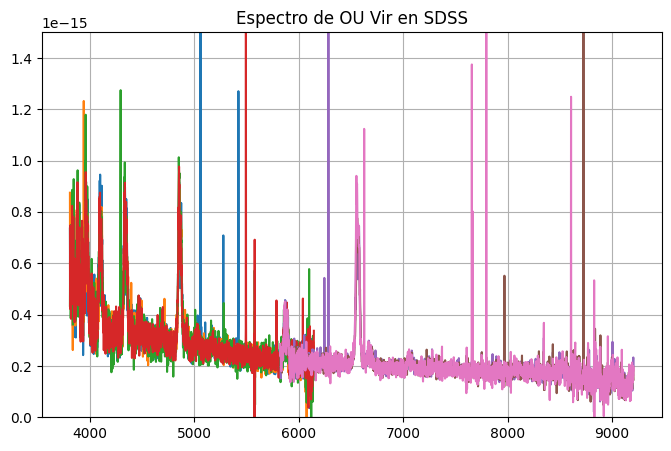

In [52]:
fx= OU_vir_sdss[4].data['flux']
londa= 10**OU_vir_sdss[4].data['loglam']


fx2= OU_vir_sdss[5].data['flux']
londa2= 10**OU_vir_sdss[5].data['loglam']

fx3= OU_vir_sdss[6].data['flux']
londa3= 10**OU_vir_sdss[6].data['loglam']

fx4= OU_vir_sdss[7].data['flux']
londa4= 10**OU_vir_sdss[7].data['loglam']


#azul

fx5= OU_vir_sdss[8].data['flux']
londa5= 10**OU_vir_sdss[8].data['loglam']

fx6= OU_vir_sdss[9].data['flux']
londa6= 10**OU_vir_sdss[9].data['loglam']

fx7= OU_vir_sdss[10].data['flux']
londa7= 10**OU_vir_sdss[10].data['loglam']

plt.figure(figsize=(8,5))
plt.title('Espectro de OU Vir en SDSS')
plt.grid('on')
plt.plot(londa,fx*1E-17)
plt.plot(londa2,fx2*1E-17)
plt.plot(londa3,fx3*1E-17)
plt.plot(londa4,fx4*1E-17)
#plt.xlim(6520, 6610)


plt.plot(londa5,fx5*1E-17)
plt.plot(londa6,fx6*1E-17)
plt.plot(londa7,fx7*1E-17)


plt.ylim(0,1.5E-15)

In [53]:

print( 'OU_vir tiene:  ',OU_vir_sdss[0].header['NEXP'], 'exposiciones y un tiempo de exposición de:  ', OU_vir_sdss[0].header['EXPTIME'], 'segundos' )

OU_vir tiene:   8 exposiciones y un tiempo de exposición de:   3600.0 segundos


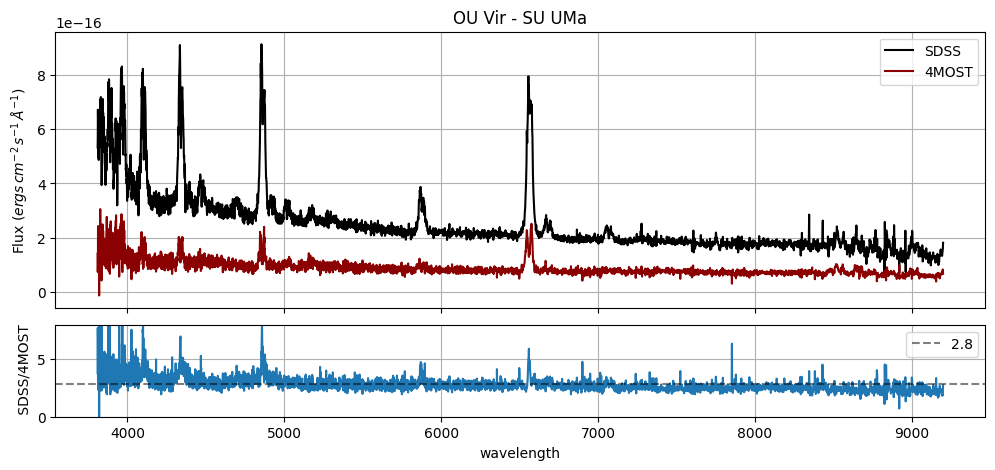

In [54]:
#NO FUNCCIONA POR LO MISMO, CAMBIARON LOS INDICES DE LOS ESPECTROS PORQUE ESTAN REORDENADOS EN LA NUEVA CARPETA
# probamos dividiendo los espectros
ou_vir_sdss= open_single_spectrum_SDSS('sdss_specs/spec_cv_SDSSJ143500.22-004606.3.fits')
ou_vir_4most= db_4most[16]
div= (ou_vir_sdss['flux'] *1E-17) / ou_vir_4most['flux']


plt.figure(figsize=(12,5))
gs= gridspec.GridSpec(2,1, height_ratios=[3,1], hspace=0.09)
ax0= plt.subplot(gs[0])

plt.setp(ax0.get_xticklabels(), visible=False)

#plt.plot(ou_vir_sdss['wavelength'], div)
ax0.plot(ou_vir_sdss['wavelength'], ou_vir_sdss['flux'] *1E-17, color='black',label='SDSS')
ax0.plot(ou_vir_4most['wavelength'], ou_vir_4most['flux'] , color='darkred', label='4MOST')
#ax0.set_xlabel('Wavelength')
ax0.set_ylabel(r'Flux ($ ergs\,cm^{-2}\,s^{-1}\,\AA^{-1}$)')
ax0.set_title('OU Vir - SU UMa')
ax0.grid('on')
ax0.legend()


ax1= plt.subplot(gs[1], sharex=ax0)
ax1.plot(ou_vir_sdss['wavelength'], div)
ax1.set_xlabel('wavelength')
ax1.set_ylim(0,8)
ax1.set_ylabel(' SDSS/4MOST')
ax1.axhline(2.8, color='black',alpha=0.5, linestyle='--',label= 2.8)
ax1.legend()
ax1.grid('on')
plt.show()


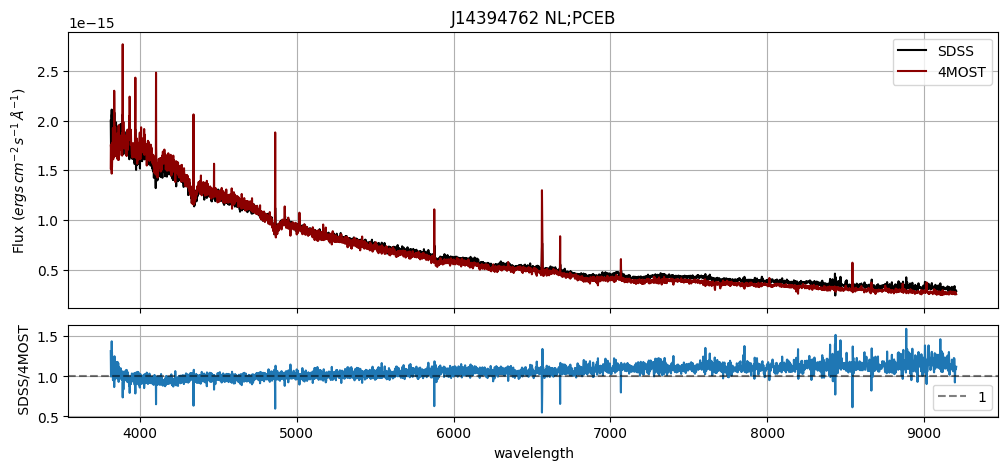

In [55]:
#hacemos lo mismo con el espectro J143947
# probamos dividiendo los espectros
SDSS_J1439= open_single_spectrum_SDSS('sdss_specs/spec_cv_SDSSJ143947.6-010606.8.fits')
J1439_4most= db_4most[19]
div= (SDSS_J1439['flux'] *1E-17) / J1439_4most['flux']


plt.figure(figsize=(12,5))
gs= gridspec.GridSpec(2,1, height_ratios=[3,1], hspace=0.09)
ax0= plt.subplot(gs[0])

plt.setp(ax0.get_xticklabels(), visible=False)

#plt.plot(SDSS_J1439['wavelength'], div)
ax0.plot(SDSS_J1439['wavelength'], SDSS_J1439['flux'] *1E-17, color='black',label='SDSS')
ax0.plot(J1439_4most
['wavelength'], J1439_4most
['flux'] , color='darkred', label='4MOST')
#ax0.set_xlabel('Wavelength')
ax0.set_ylabel(r'Flux ($ ergs\,cm^{-2}\,s^{-1}\,\AA^{-1}$)')
ax0.set_title('J14394762 NL;PCEB')
ax0.grid('on')
ax0.legend()


ax1= plt.subplot(gs[1], sharex=ax0)
ax1.plot(SDSS_J1439['wavelength'], div)
ax1.set_xlabel('wavelength')
#ax1.set_ylim(0,8)
ax1.set_ylabel(' SDSS/4MOST')
ax1.axhline(1, color='black',alpha=0.5, linestyle='--', label='1')
ax1.legend()
ax1.grid('on')
plt.show()


Match encontrado a 0.15 arcsec de distancia.


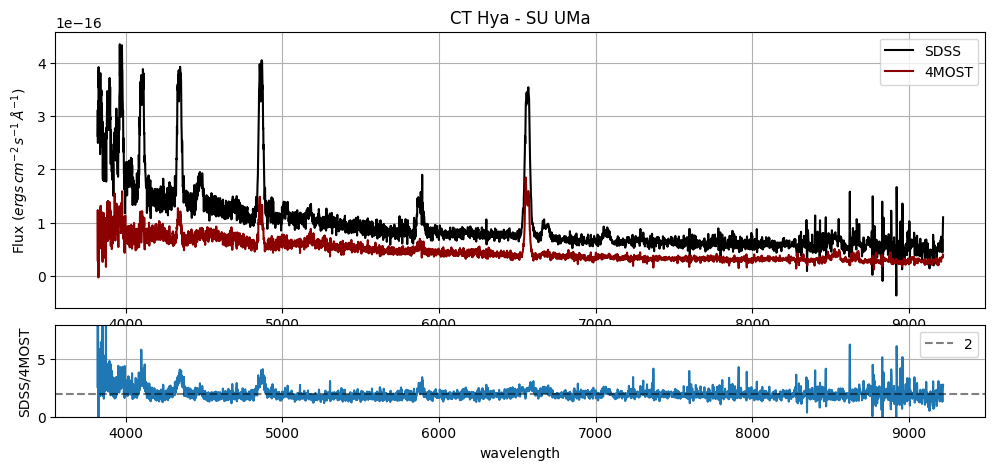

In [56]:
# CT Hya
# probamos dividiendo los espectros
ct_hya_sdss= cross_match(db_4most[7],db_sdss)
ct_hya_4most= db_4most[7]
div= (ct_hya_sdss['flux'] *1E-17) / ct_hya_4most['flux']


plt.figure(figsize=(12,5))
gs= gridspec.GridSpec(2,1, height_ratios=[3,1], hspace=0.09)
ax0= plt.subplot(gs[0])

#plt.setp(ax0.get_xticklabels(), visible=False)

#plt.plot(ct_hya_sdss['wavelength'], div)
ax0.plot(ct_hya_sdss['wavelength'], ct_hya_sdss['flux'] *1E-17, color='black',label='SDSS')
ax0.plot(ct_hya_4most['wavelength'], ct_hya_4most['flux'] , color='darkred', label='4MOST')
#ax0.set_xlabel('Wavelength')
ax0.set_ylabel(r'Flux ($ ergs\,cm^{-2}\,s^{-1}\,\AA^{-1}$)')
ax0.set_title('CT Hya - SU UMa')
ax0.grid('on')
ax0.legend()


ax1= plt.subplot(gs[1], sharex=ax0)
ax1.plot(ct_hya_sdss['wavelength'], div)
ax1.set_xlabel('wavelength')
ax1.set_ylim(0,8)
ax1.set_ylabel('SDSS/4MOST')
ax1.axhline(2, color='black',alpha=0.5, linestyle='--', label= '2')
ax1.legend()
ax1.grid('on')
plt.show()

Match encontrado a 0.55 arcsec de distancia.


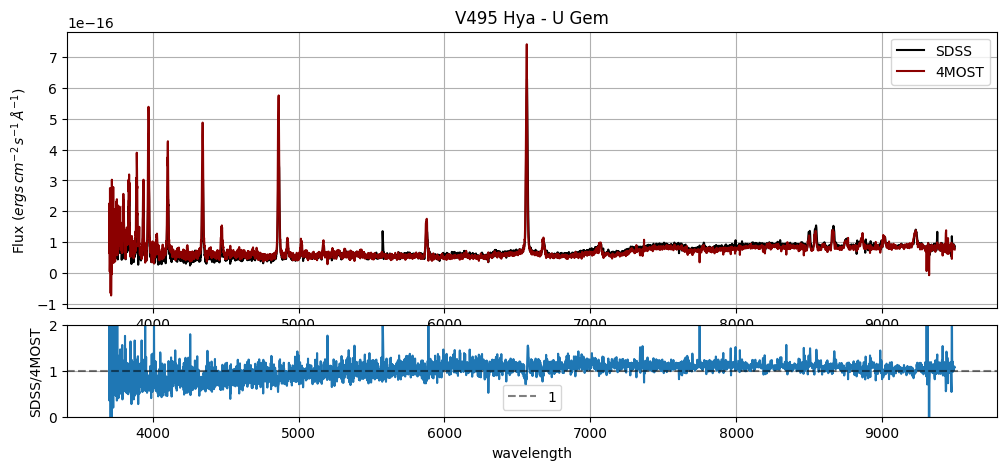

In [57]:
#hacemos lo mismo con V495 Hya
# probamos dividiendo los espectros
V495_Hya= cross_match(db_4most[3],db_sdss)
V495_Hya_4most= db_4most[3]
div= (V495_Hya['flux'] *1E-17) / V495_Hya_4most['flux']


plt.figure(figsize=(12,5))
gs= gridspec.GridSpec(2,1, height_ratios=[3,1], hspace=0.09)
ax0= plt.subplot(gs[0])

#plt.setp(ax0.get_xticklabels(), visible=False)

#plt.plot(V495_Hya['wavelength'], div)
ax0.plot(V495_Hya['wavelength'], V495_Hya['flux'] *1E-17, color='black',label='SDSS')
ax0.plot(V495_Hya_4most['wavelength'], V495_Hya_4most['flux'] , color='darkred', label='4MOST')
#ax0.set_xlabel('Wavelength')
ax0.set_ylabel(r'Flux ($ ergs\,cm^{-2}\,s^{-1}\,\AA^{-1}$)')
ax0.set_title('V495 Hya - U Gem')
ax0.grid('on')
ax0.legend()


ax1= plt.subplot(gs[1], sharex=ax0)
ax1.plot(V495_Hya['wavelength'], div)
ax1.set_xlabel('wavelength')
ax1.set_ylim(0,2)
ax1.set_ylabel('SDSS/4MOST')
ax1.axhline(1, color='black',alpha=0.5, linestyle='--', label= '1')
ax1.legend()
ax1.grid('on')
plt.show()

### Histograma de los residuos 

Match encontrado a 0.11 arcsec de distancia.


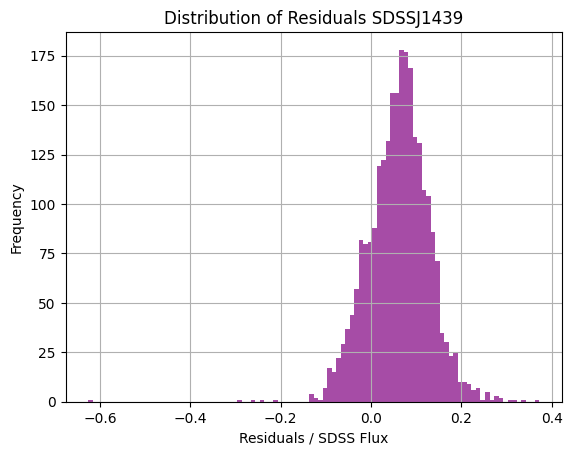

In [58]:
# prueba 1
cont, mask, lines= mask_lines(db_4most[19])
flux_con_4most= db_4most[19]['flux'][mask]
flux_con_sdss= cross_match(db_4most[19], db_sdss)['flux'][mask] *1E-17

residuos= flux_con_sdss - flux_con_4most
residuos_relativos= residuos / flux_con_sdss

plt.hist(residuos_relativos, bins=100, color= 'purple', alpha=0.7)
#plt.hist(residuos, bins=50, color= 'purple', alpha=0.7)
plt.xlabel('Residuals / SDSS Flux')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals SDSSJ1439')
plt.grid('on')
plt.show()

In [59]:
residuos_relativos

array([ 0.0081535 , -0.01426077,  0.04116879, ...,  0.08450984,
        0.08075391,  0.10717591], shape=(2584,), dtype=float32)

In [60]:
# ahora usando distintos anchos con el calculo puro
londa_inicio= db_4most[19]['wavelength'][0]
wave_con= db_4most[19]['wavelength'][mask]
anchos= np.arange( 10,2000,50)
medias= []
desv= []


flux_sdss_nan= cross_match(db_4most[19], db_sdss)['flux'].copy() *1E-17
flux_sdss_nan[~mask]= np.nan
flux_4most_nan= db_4most[19]['flux'].copy()
flux_4most_nan[~mask]= np.nan
residuos_nan= flux_sdss_nan - flux_4most_nan


for ancho in anchos:
    
    
    lim_izq= londa_inicio  #le damos el mismo inicio para todos los anchos 
    lim_der= londa_inicio + ancho   # vamos ensanchando hacia la derecha 
    mask_anchos= (wave_con >= lim_izq) & (wave_con <= lim_der)    #mascara para permitir sólo los puntos dentro de ese ancho
    
    residuos_ventana= residuos_relativos[mask_anchos]      # dejamos los residuals de esa región
    
    medias.append(np.nanmedian(residuos_ventana))     # calulamos la media y desv para esa ventana y los guardamos para luego graficar
    desv.append(np.nanstd(residuos_ventana))

Match encontrado a 0.11 arcsec de distancia.


c:\Users\paisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\paisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\s'
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\1467570033.py:62: SyntaxWarning: invalid escape sequence '\m'
  ax_hist.text(0.75, 0.85, f'$\mu$: {mu:.4f}\n$\sigma$: {sigma:.4f}',
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\1467570033.py:62: SyntaxWarning: invalid escape sequence '\s'
  ax_hist.text(0.75, 0.85, f'$\mu$: {mu:.4f}\n$\sigma$: {sigma:.4f}',


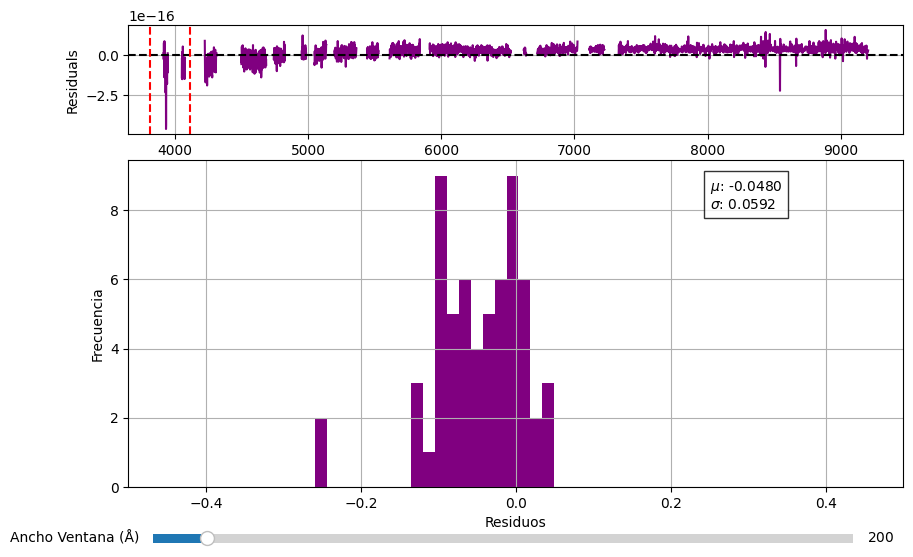

In [61]:
# y aquí usando distintos anchos pero con el calculo de cada región en el momento
#%matplotlib qt5

from matplotlib.widgets import Slider

londa_inicio= db_4most[19]['wavelength'][0]
wave_con= db_4most[19]['wavelength'][mask]
anchos= np.arange( 10,2000,50)


fig= plt.figure(figsize=(10,6))
gs= gridspec.GridSpec(2,1, height_ratios=[1,3], hspace=0.12)
ax_res= plt.subplot(gs[0])
ax_hist= plt.subplot(gs[1])


ax_res.plot(db_4most[19]['wavelength'], residuos_nan, color='purple')
ax_res.set_xlabel('Wavelength')
ax_res.set_ylabel('Residuals')
ax_res.axhline(0, color='black', linestyle='--') # Línea en el cero para guiar el ojo
ax_res.grid('on')
#franja= ax_res.axvspan(wave_con[0], wave_con[0]+50, color='orange', alpha=0.3) # por checar
linea_izq = ax_res.axvline(lim_izq , color='red', linestyle='--')
linea_der = ax_res.axvline(lim_der, color='red', linestyle='--')

ax_hist.grid('on')
# creamos el eje y el objeto slider
ax_slider = plt.axes([0.15, 0.01, 0.7, 0.03]) # [x, y, ancho, alto] (creo que x e y son la posición del slider)
slider_ancho = Slider(
    ax=ax_slider,
    label='Ancho Ventana (Å)',
    valmin=50,
    valmax=2000,
    valinit=200,   # Valor con el que arranca
    valstep=50     # Saltos de 50 en 50
)

def update(val):   #creamos una función para que me actualice con cada cambio del slider
    ancho_actual= slider_ancho.val  #obtenemos el valor actual del slider
    lim_izq= wave_con[0]  #le damos el mismo inicio para
    lim_der= wave_con[0] + ancho_actual   # vamos ensanchando hacia la derecha
    #franja.set_xy([[lim_izq, 0], [lim_der, 0], [lim_der, 1], [lim_izq, 1]]) #actualizamos la posición de la franja en el gráfico de residuos    
    linea_der.set_xdata([lim_der, lim_der])



    mascara = (wave_con >= lim_izq) & (wave_con <= lim_der)
    residuos_ventana = residuos_relativos[mascara]
    
    # para limpiar el panel del histograma (ax_hist) y redibujar
    ax_hist.cla() # Clear axis
    ax_hist.hist(residuos_ventana, bins=20, color='purple')
    ax_hist.set_xlim(-0.5, 0.5) # Fija los límites X para que el gráfico no salte mareando al usuario
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.set_xlabel('Residuos')
    ax_hist.grid('on')
    # calculamos media y desviación estándar para mostrar en el texto dinámico
    mu = np.nanmean(residuos_ventana)
    sigma = np.nanstd(residuos_ventana)
    
    # para colocar el  plt.text dinámico
    ax_hist.text(0.75, 0.85, f'$\mu$: {mu:.4f}\n$\sigma$: {sigma:.4f}', 
                 transform=ax_hist.transAxes, 
                 bbox=dict(facecolor='white', alpha=0.8))
    
    # refrescar la pantalla para mostrar los cambios
    fig.canvas.draw_idle()

#  Conectamos el slider con la función update e inicializar
slider_ancho.on_changed(update)
update(slider_ancho.val) # Llamada manual para dibujar el estado inicial

#plt.show()


### Todos los sistemas 
V406 Vir (WZ Sge)

J1240-0159 (AM CVn)


J1446+0253 (Intermediate polar)


V519 Ser (Polar)

#### qmost_1446+0253

Match encontrado a 0.10 arcsec de distancia.


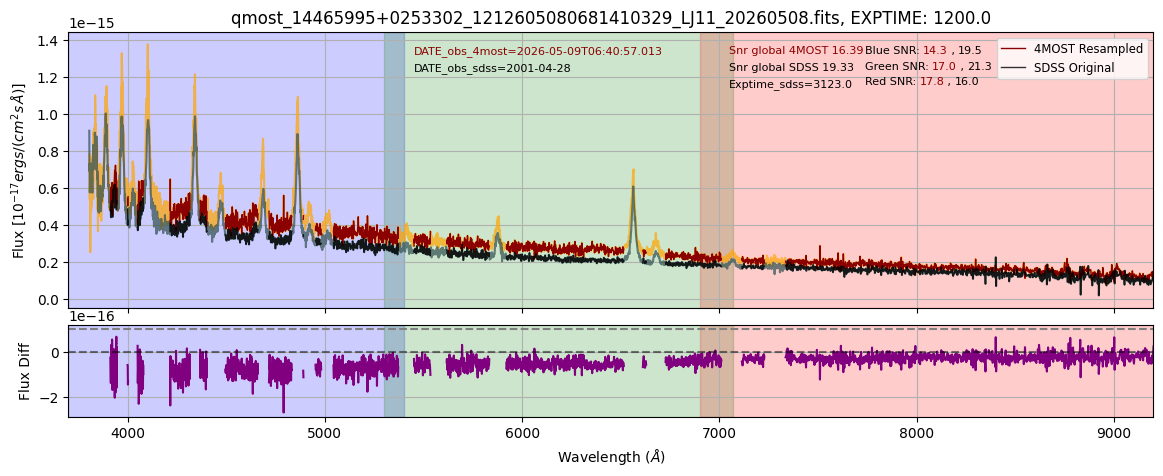

In [62]:
#Vamos primero con los residuals, pero antes les asignamos nombres para que salgan con el tag del sistema

n= 23
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)


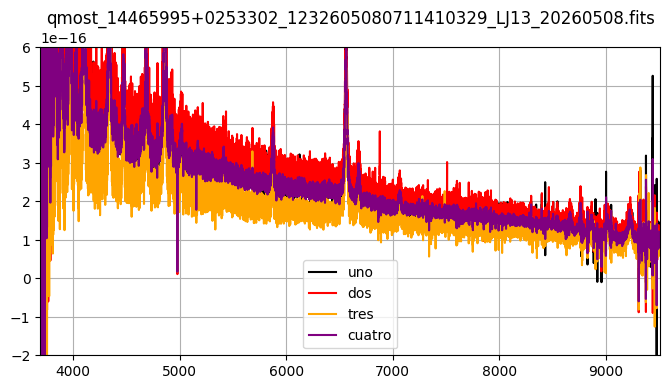

In [63]:
uno= open_single_spectrum_4MOST('CVs2/qmost_14465995+0253302_1212605080651410329_LJ11_20260508.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_14465995+0253302_1212605080681410329_LJ11_20260508.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_14465995+0253302_1212605080711410329_LJ11_20260508.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_14465995+0253302_1232605080711410329_LJ13_20260508.fits')


plt.figure(figsize=(8,4))
plt.title(cuatro['filename'])
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
plt.xlim(3690, 9510)
plt.legend()
plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

#### V406 Vir (WZ Sge) qmost_1238-0339

Match encontrado a 2.41 arcsec de distancia.


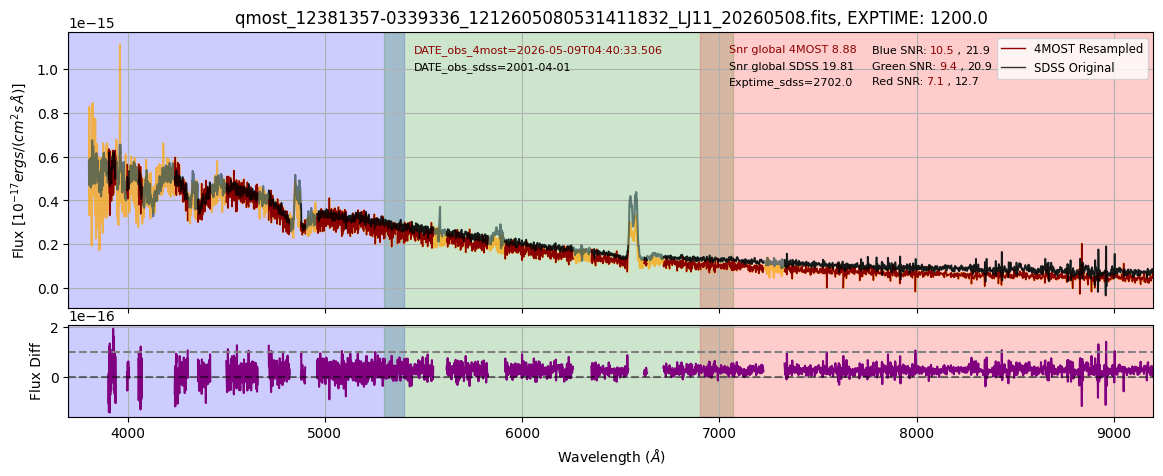

In [64]:
n= 8   #Este es V406 Vir (WZ Sge) LJ11
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

Match encontrado a 2.41 arcsec de distancia.


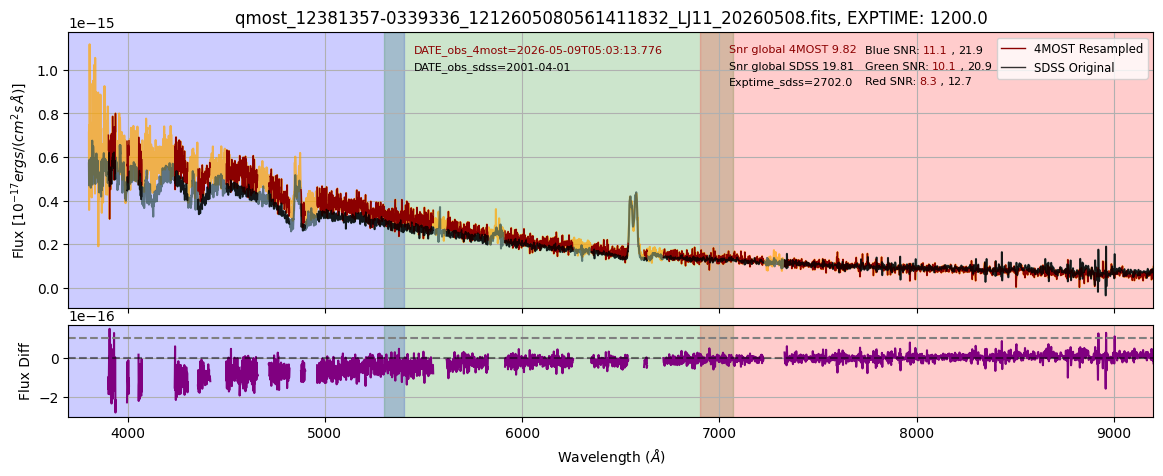

In [65]:
n= 9   #Este es V406 Vir (WZ Sge) LJ11
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

Match encontrado a 2.41 arcsec de distancia.


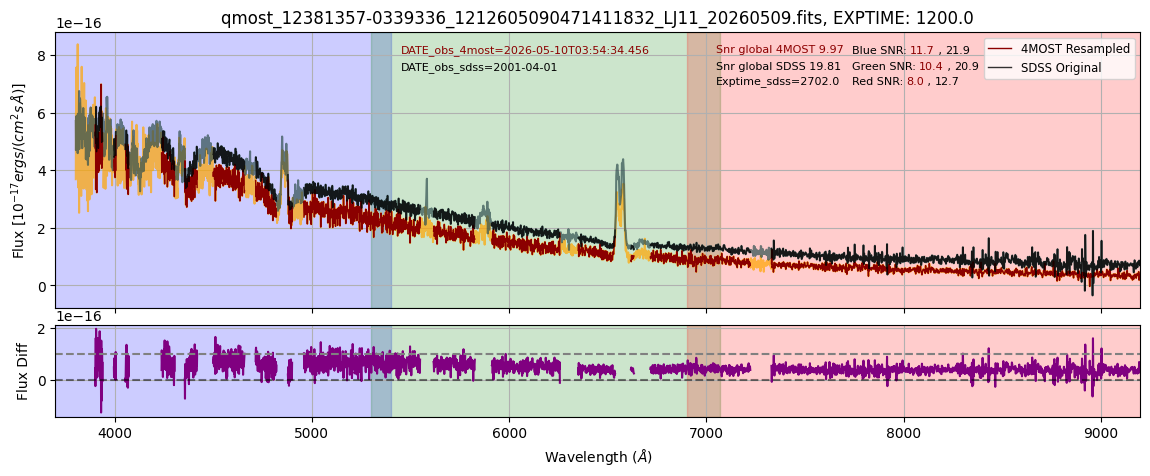

In [66]:
n= 10   #Este es V406 Vir (WZ Sge) LJ11
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

Match encontrado a 2.41 arcsec de distancia.


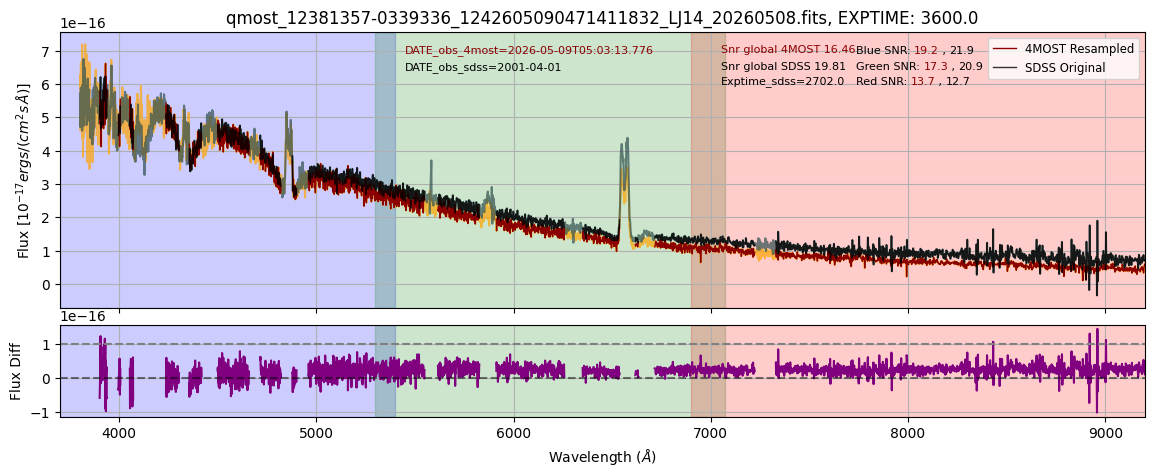

In [67]:
n= 11   #Este es V406 Vir (WZ Sge) LJ14 (no sé a que se refiere con 14)
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:44: RuntimeWarning: invalid value encountered in divide
  snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err


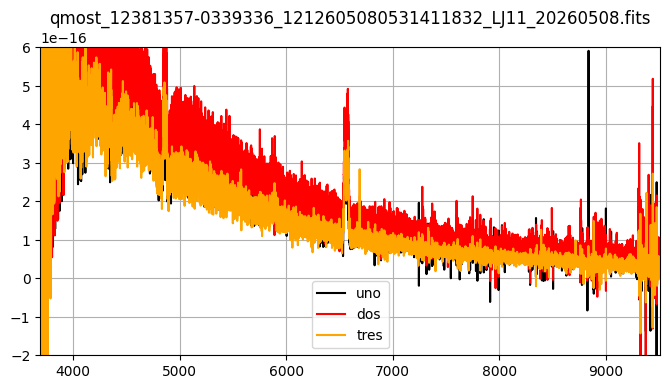

In [68]:
uno= open_single_spectrum_4MOST('CVs2/qmost_12381357-0339336_1212605080531411832_LJ11_20260508.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_12381357-0339336_1212605080561411832_LJ11_20260508.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_12381357-0339336_1212605090471411832_LJ11_20260509.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_12381357-0339336_1242605090471411832_LJ14_20260508.fits')


plt.figure(figsize=(8,4))
plt.title(uno['filename'])
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
#plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
plt.xlim(3690, 9510)
plt.legend()
plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

#### qmost_20482791+0050...

Match encontrado a 0.13 arcsec de distancia.


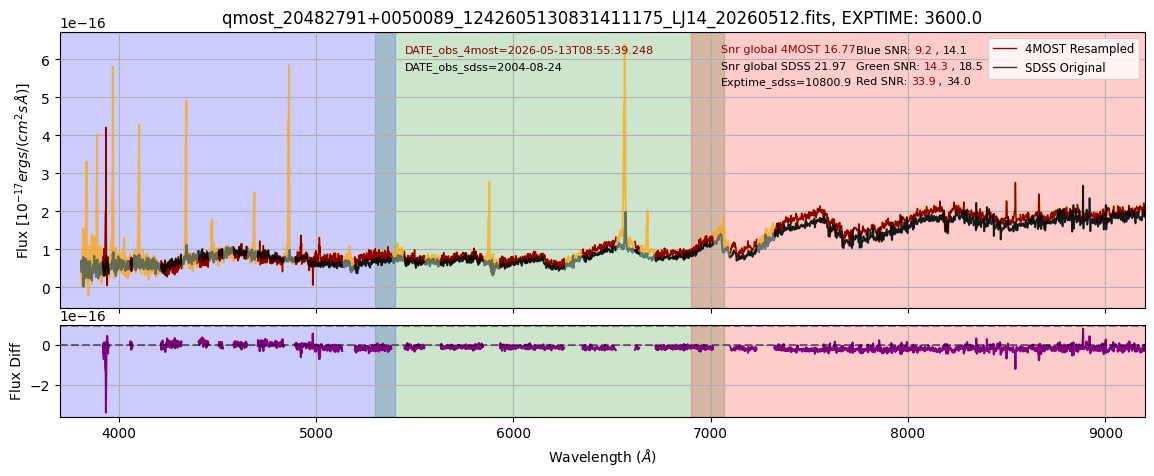

In [69]:

n= 44
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:43: RuntimeWarning: invalid value encountered in divide
  snr_green = np.nanmedian(flux[idx_green] / (err[idx_green]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err


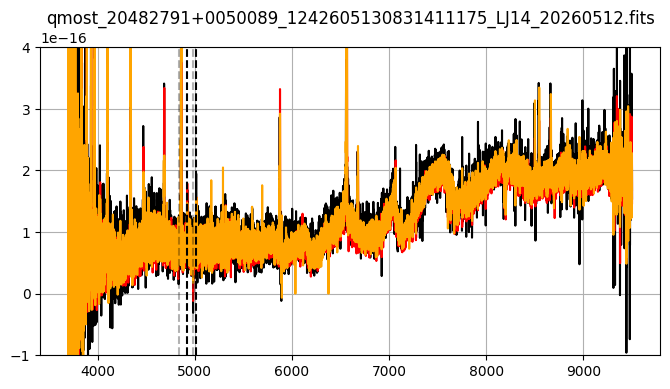

In [70]:
#%matplotlib qt5
uno=open_single_spectrum_4MOST('CVs2/qmost_20482791+0050089_1212605120891411175_LJ11_20260512.fits')
dos=open_single_spectrum_4MOST('CVs2/qmost_20482791+0050089_1212605130801411175_LJ11_20260513.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_20482791+0050089_1212605130831411175_LJ11_20260513.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_20482791+0050089_1242605130831411175_LJ14_20260512.fits')


plt.figure(figsize=(8,4))
plt.title(cuatro['filename'])
plt.plot(uno['wavelength'], uno['flux'], color='black', label='uno')
plt.plot(dos['wavelength'], dos['flux'], color='red', label='dos')
plt.plot(tres['wavelength'], tres['flux'], color='orange', label='tres')
#plt.plot(cuatro['wavelength'], cuatro['flux'])
#plt.xlim(4950, 5015)
plt.axvline(5017, color='black', linestyle='--')
plt.axvline(4923, color='black', linestyle='--')
plt.axvline(4983, color='black', linestyle='--', alpha=0.3)
plt.axvline(4833, color='black', linestyle='--', alpha=0.3)   #por corroborar
plt.ylim(-1E-16, 0.4E-15)
plt.grid('on')

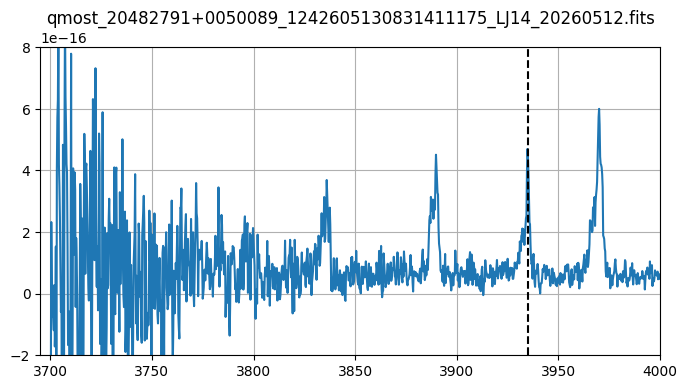

In [71]:
plt.figure(figsize=(8,4))
plt.title(cuatro['filename'])
#plt.plot(uno['wavelength'], uno['flux'])
#plt.plot(dos['wavelength'], dos['flux'])
#plt.plot(tres['wavelength'], tres['flux'])
plt.plot(cuatro['wavelength'], cuatro['flux'])
plt.xlim(3695, 4000)
#plt.axvline(4983, color='black', linestyle='--', alpha=0.3)
plt.axvline(3935, color='black', linestyle='--')
plt.ylim(-2E-16, 8*1E-16)
plt.grid('on')

#### J1240 qmost_12405802

Match encontrado a 0.12 arcsec de distancia.


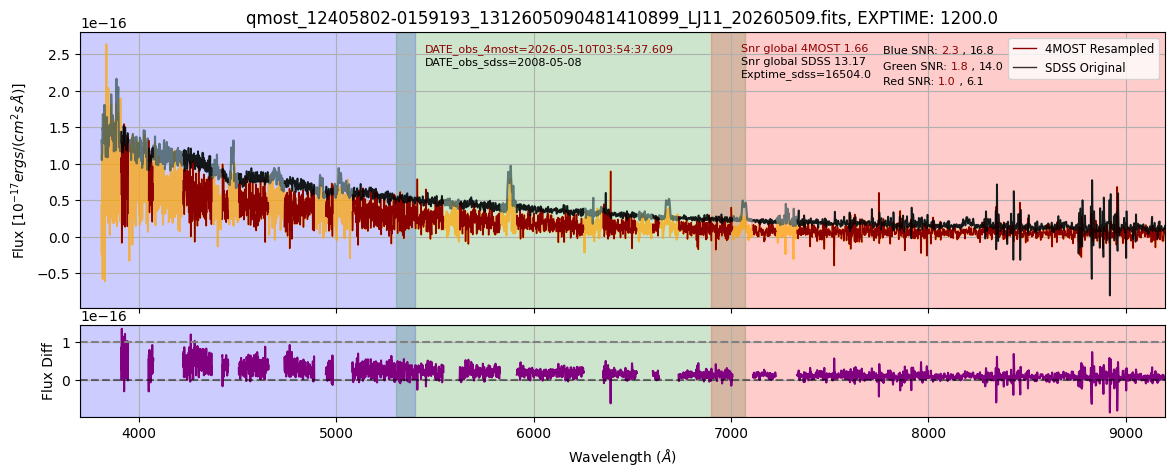

In [72]:
n= 14  # este es el que se ve bueno, los demás andan mal
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:42: RuntimeWarning: invalid value encountered in divide
  snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:43: RuntimeWarning: invalid value encountered in divide
  snr_green = np.nanmedian(flux[idx_green] / (err[idx_green]))


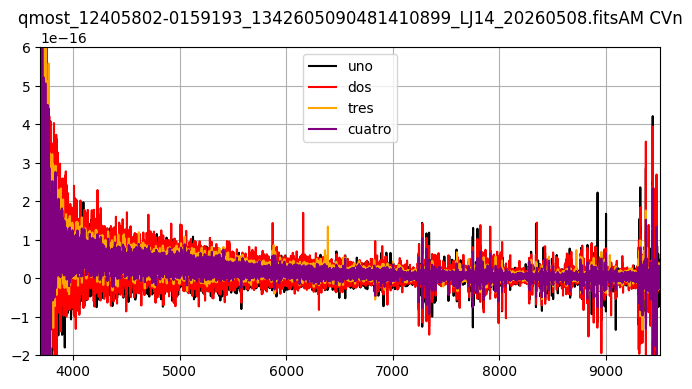

In [73]:
uno= open_single_spectrum_4MOST('CVs2/qmost_12405802-0159193_1312605080541410899_LJ11_20260508.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_12405802-0159193_1312605080571410899_LJ11_20260508.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_12405802-0159193_1312605090481410899_LJ11_20260509.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_12405802-0159193_1342605090481410899_LJ14_20260508.fits')


plt.figure(figsize=(8,4))
plt.title(cuatro['filename']+'AM CVn')
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
plt.xlim(3690, 9510)
plt.legend()
plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

#### qmost_204817-0610

Match encontrado a 0.35 arcsec de distancia.


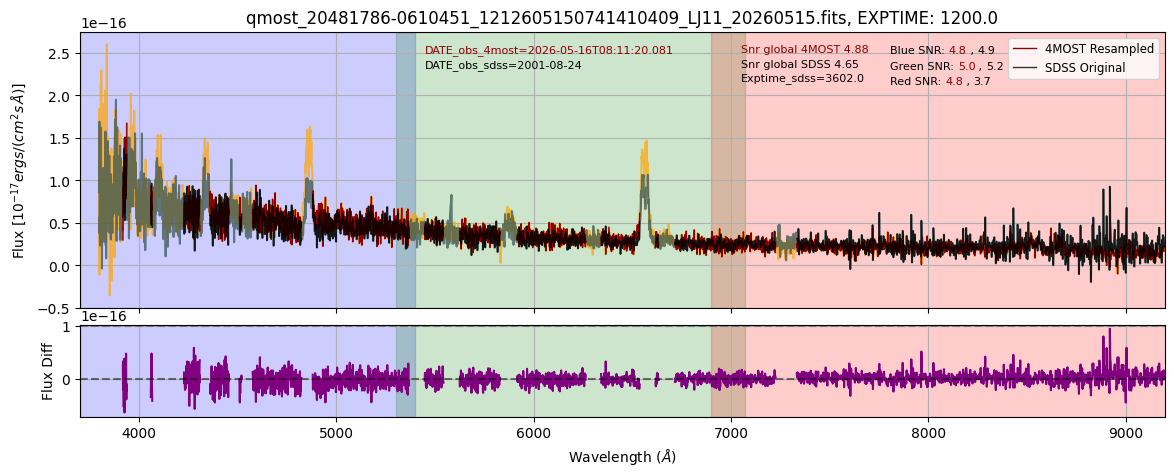

In [74]:
n= 39   # este es el que se ve bueno, los demás andan mal
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:43: RuntimeWarning: invalid value encountered in divide
  snr_green = np.nanmedian(flux[idx_green] / (err[idx_green]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err


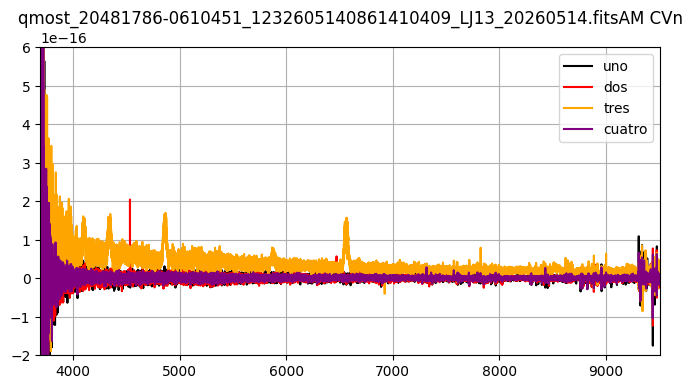

In [75]:
uno= open_single_spectrum_4MOST('CVs2/qmost_20481786-0610451_1212605140831410409_LJ11_20260514.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_20481786-0610451_1212605140861410409_LJ11_20260514.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_20481786-0610451_1212605150741410409_LJ11_20260515.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_20481786-0610451_1232605140861410409_LJ13_20260514.fits')


plt.figure(figsize=(8,4))
plt.title(cuatro['filename']+'AM CVn')
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
plt.xlim(3690, 9510)
plt.legend()
plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

#### V519 Ser qmost_1610+03523

Match encontrado a 0.15 arcsec de distancia.


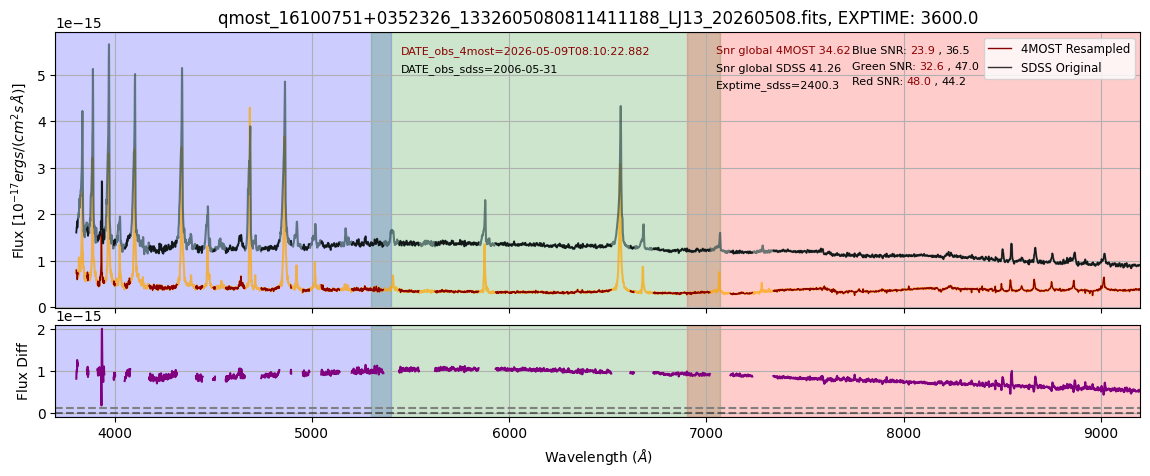

In [76]:
n= 29
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

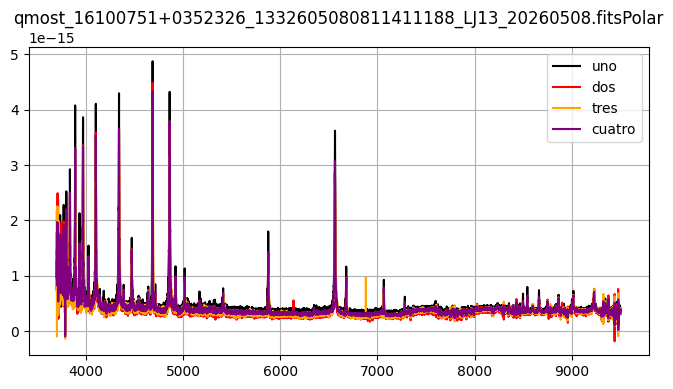

In [77]:
uno= open_single_spectrum_4MOST('CVs2/qmost_16100751+0352326_1312605080751411188_LJ11_20260508.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_16100751+0352326_1312605080781411188_LJ11_20260508.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_16100751+0352326_1312605080811411188_LJ11_20260508.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_16100751+0352326_1332605080811411188_LJ13_20260508.fits')


plt.figure(figsize=(8,4))
plt.title(cuatro['filename']+'Polar')
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
#plt.xlim(3690, 4000)
#plt.xlim(3750,3800)
plt.legend()
#plt.axvline(3935, color='black', linestyle='--')
#plt.axvline(3786, color='black', linestyle='--')
#plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

#### V495 Hya 

Match encontrado a 0.55 arcsec de distancia.


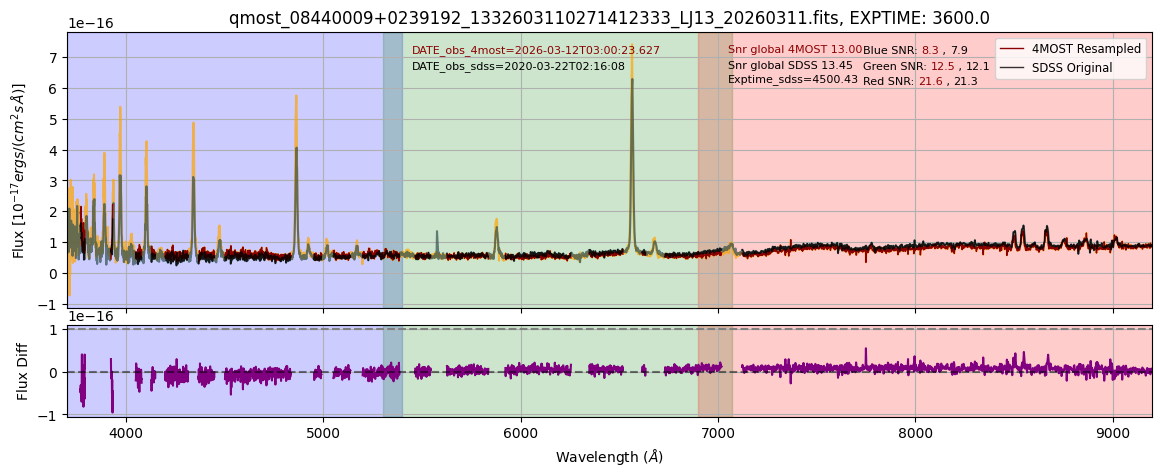

In [78]:
n= 3
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:44: RuntimeWarning: invalid value encountered in divide
  snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err


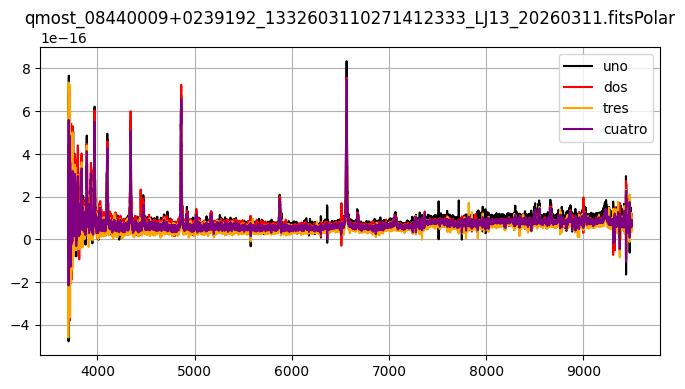

In [79]:
uno= open_single_spectrum_4MOST('CVs2/qmost_08440009+0239192_1312603110211412333_LJ11_20260311.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_08440009+0239192_1312603110241412333_LJ11_20260311.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_08440009+0239192_1312603110271412333_LJ11_20260311.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_08440009+0239192_1332603110271412333_LJ13_20260311.fits')


plt.figure(figsize=(8,4))
plt.title(cuatro['filename']+'Polar')
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
#plt.xlim(3690, 4000)
#plt.xlim(3750,3800)
plt.legend()
#plt.axvline(3935, color='black', linestyle='--')
#plt.axvline(3786, color='black', linestyle='--')
#plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

#### CT Hya

Match encontrado a 0.15 arcsec de distancia.


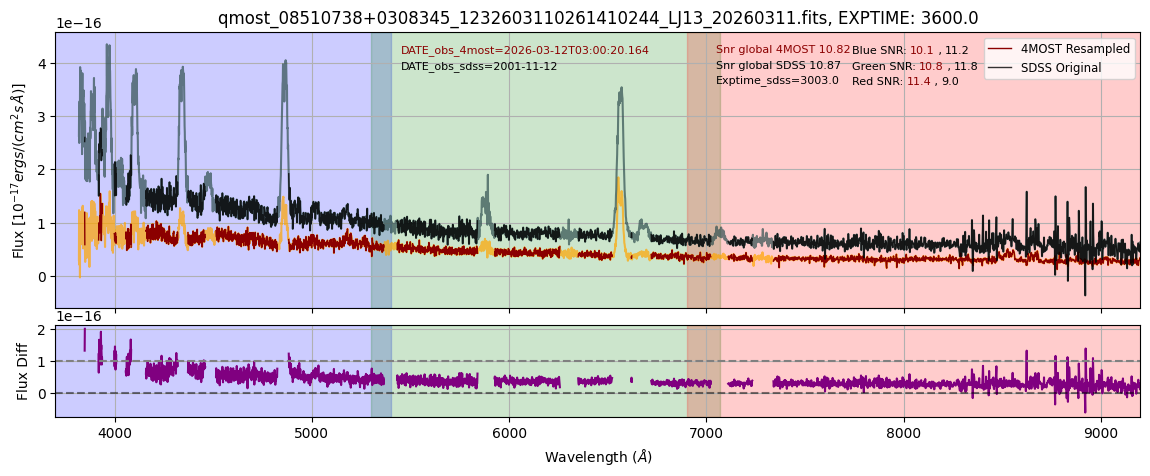

In [80]:
n= 7
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

modificar exposiciones 

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:44: RuntimeWarning: invalid value encountered in divide
  snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err


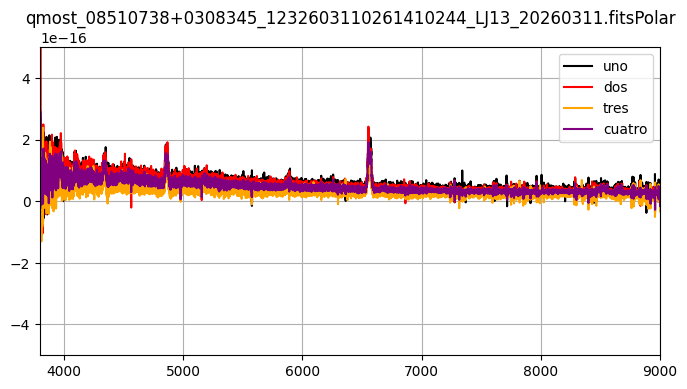

In [81]:
uno= open_single_spectrum_4MOST('CVs2/qmost_08510738+0308345_1212603110201410244_LJ11_20260311.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_08510738+0308345_1212603110231410244_LJ11_20260311.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_08510738+0308345_1212603110261410244_LJ11_20260311.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_08510738+0308345_1232603110261410244_LJ13_20260311.fits')


plt.figure(figsize=(8,4))
plt.title(cuatro['filename']+'Polar')
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
plt.xlim(3800, 9000)
plt.ylim(-0.5E-15, 0.5E-15)
plt.legend()
#plt.axvline(3935, color='black', linestyle='--')
#plt.axvline(3786, color='black', linestyle='--')
#plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

#### OU Vir

Match encontrado a 0.11 arcsec de distancia.


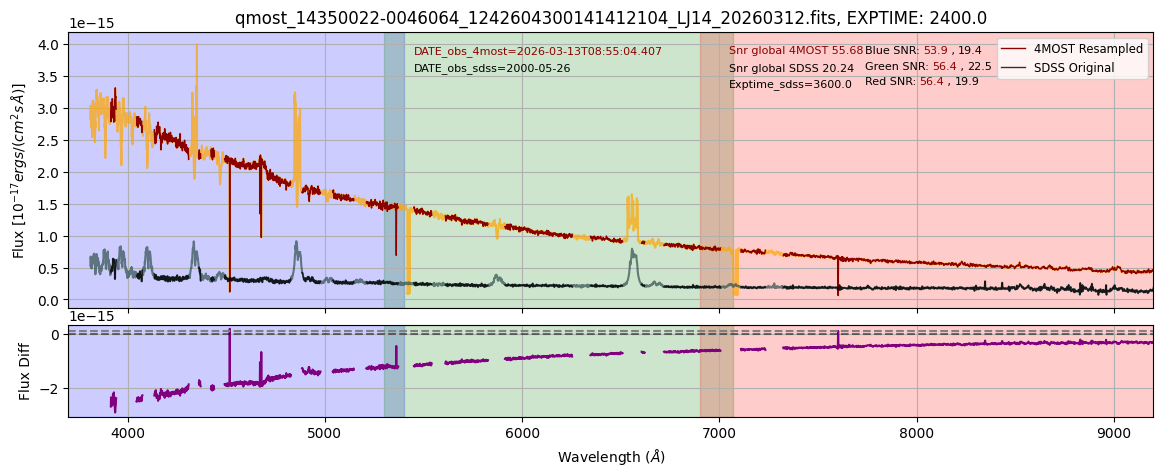

In [82]:
n= 18 # 17 al 18
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:42: RuntimeWarning: divide by zero encountered in divide
  snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:43: RuntimeWarning: divide by zero encountered in divide
  snr_green = np.nanmedian(flux[idx_green] / (err[idx_green]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:44: RuntimeWarning: divide by zero encountered in divide
  snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: divide by zero encountered in divide
  snr_array= flux/err


Error procesando : Empty filename: ''


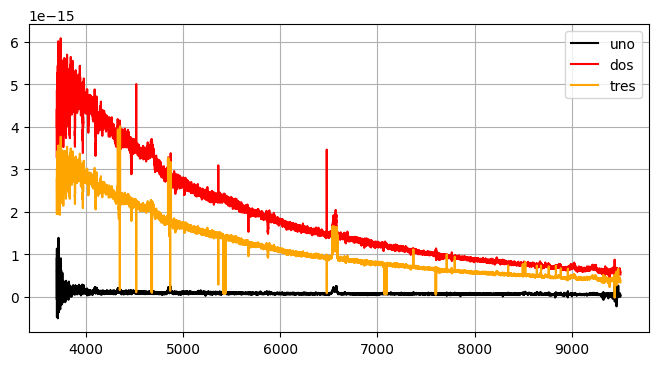

In [83]:
uno= open_single_spectrum_4MOST('CVs2/qmost_14350022-0046064_1212603120741412104_LJ11_20260312.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_14350022-0046064_1212604300141412104_LJ11_20260430.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_14350022-0046064_1242604300141412104_LJ14_20260312.fits')
cuatro= open_single_spectrum_4MOST('')


plt.figure(figsize=(8,4))
#plt.title(cuatro['filename']+'Polar')
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
#plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
#plt.xlim(3690, 4000)
#plt.xlim(3750,3800)
plt.legend()
#plt.axvline(3935, color='black', linestyle='--')
#plt.axvline(3786, color='black', linestyle='--')
#plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

#### J1439

Match encontrado a 0.11 arcsec de distancia.


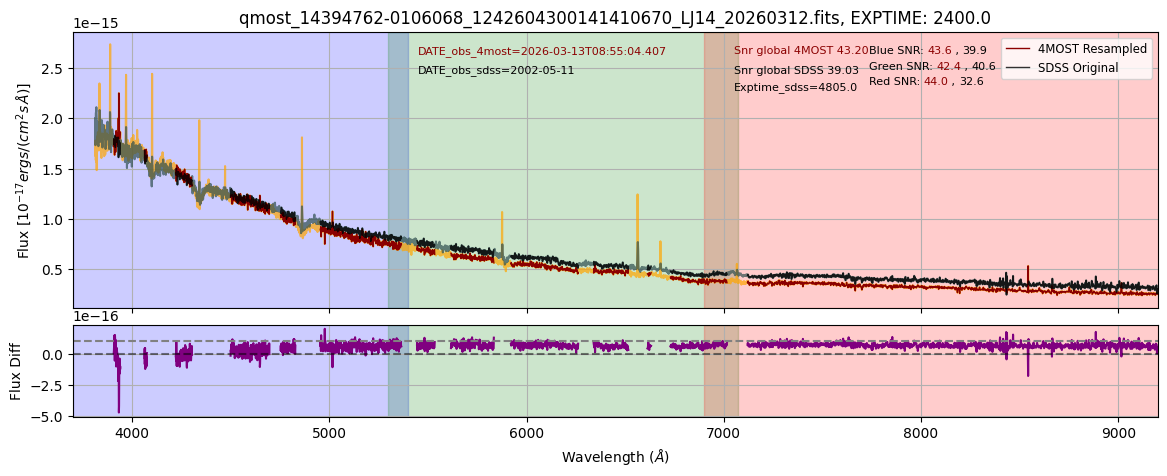

In [84]:
n= 21 #19-21    19 es el más accurate 
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

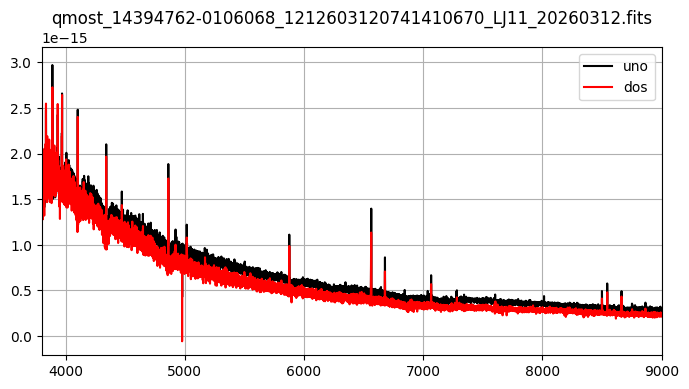

In [85]:
uno= open_single_spectrum_4MOST('CVs2/qmost_14394762-0106068_1212603120741410670_LJ11_20260312.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_14394762-0106068_1212604300141410670_LJ11_20260430.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_14394762-0106068_1242604300141410670_LJ14_20260312.fits')
#cuatro= open_single_spectrum_4MOST('')


plt.figure(figsize=(8,4))
plt.title(uno['filename'])
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
#plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
#plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
plt.xlim(3800, 9000)
#plt.ylim(-0.5E-15, 0.5E-15)
plt.legend()
#plt.axvline(3935, color='black', linestyle='--')
#plt.axvline(3786, color='black', linestyle='--')
#plt.ylim(-0.5E-15, 0.5E-15)
plt.grid('on')
plt.show()

#### qmost2044

Match encontrado a 0.02 arcsec de distancia.


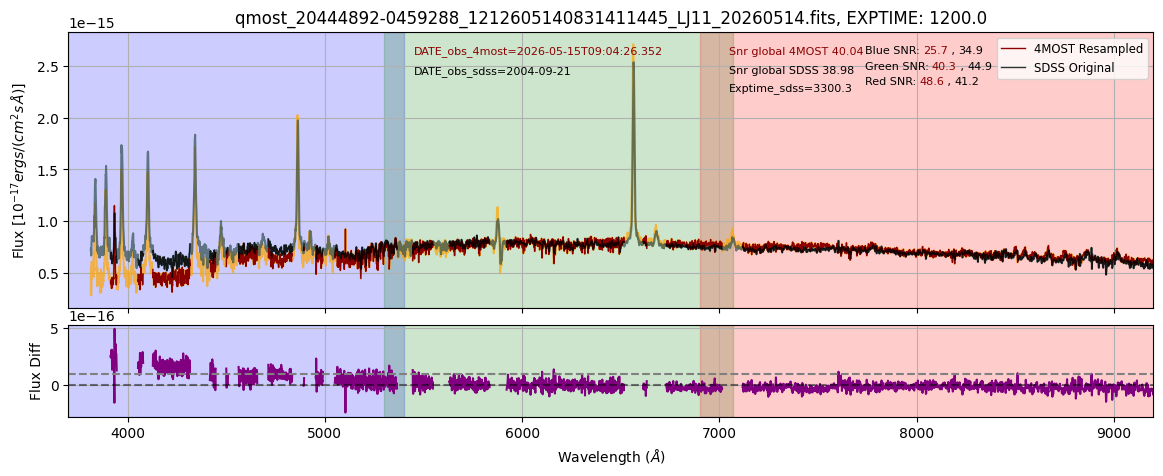

In [86]:
n= 30 #19-21    19 es el más accurate 
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

#### qmost2047

Match encontrado a 0.09 arcsec de distancia.


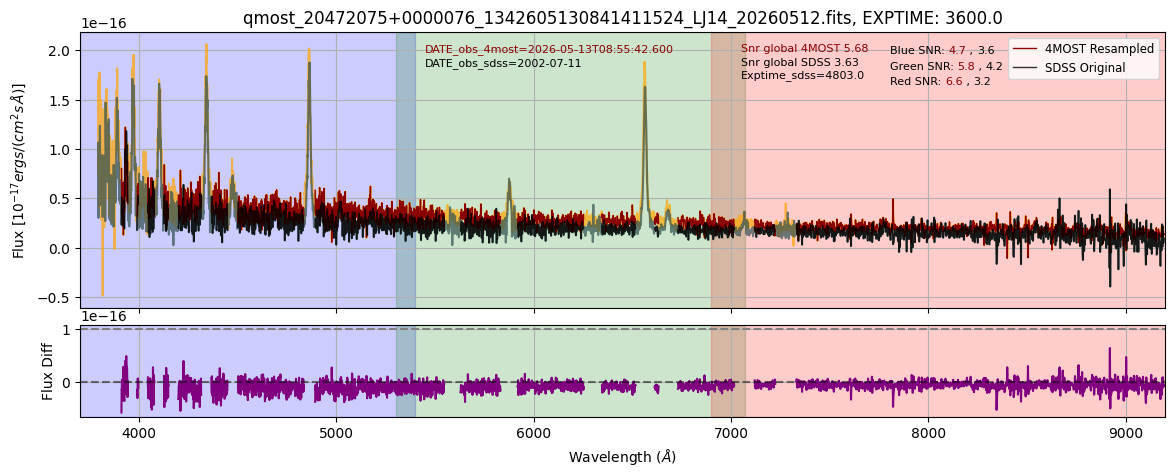

In [87]:
n= 36 #19-21    19 es el más accurate 
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos= residuals(cross_match_2,spect_n_4most,plot=True)

C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:42: RuntimeWarning: invalid value encountered in divide
  snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:44: RuntimeWarning: invalid value encountered in divide
  snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_14028\480903719.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err


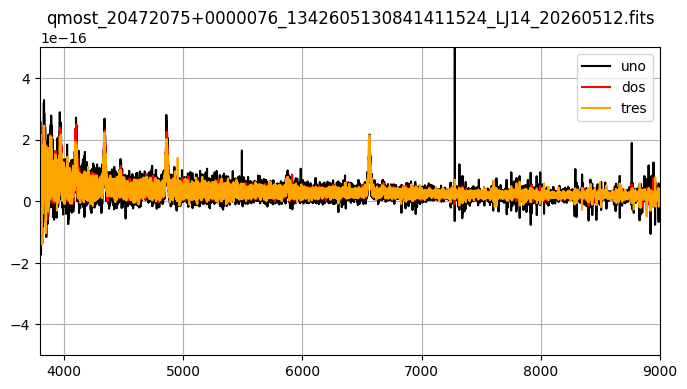

In [88]:
uno= open_single_spectrum_4MOST('CVs2/qmost_20472075+0000076_1312605120901411524_LJ11_20260512.fits')
dos= open_single_spectrum_4MOST('CVs2/qmost_20472075+0000076_1312605130811411524_LJ11_20260513.fits')
tres= open_single_spectrum_4MOST('CVs2/qmost_20472075+0000076_1312605130841411524_LJ11_20260513.fits')
cuatro= open_single_spectrum_4MOST('CVs2/qmost_20472075+0000076_1342605130841411524_LJ14_20260512.fits')


plt.figure(figsize=(8,4))
plt.title(cuatro['filename'])
plt.plot(uno['wavelength'], uno['flux'],label='uno',color='black')
plt.plot(dos['wavelength'], dos['flux'],label='dos',color='red')
plt.plot(tres['wavelength'], tres['flux'],label='tres',color='orange')
#plt.plot(cuatro['wavelength'], cuatro['flux'],label='cuatro',color='purple')
plt.xlim(3800, 9000)
plt.ylim(-0.5E-15, 0.5E-15)
plt.legend()
#plt.axvline(3935, color='black', linestyle='--')
#plt.axvline(3786, color='black', linestyle='--')
#plt.ylim(-0.2E-15, 0.6E-15)
plt.grid('on')
plt.show()

### Caracterizando la slope de los residuals

Match encontrado a 0.55 arcsec de distancia.


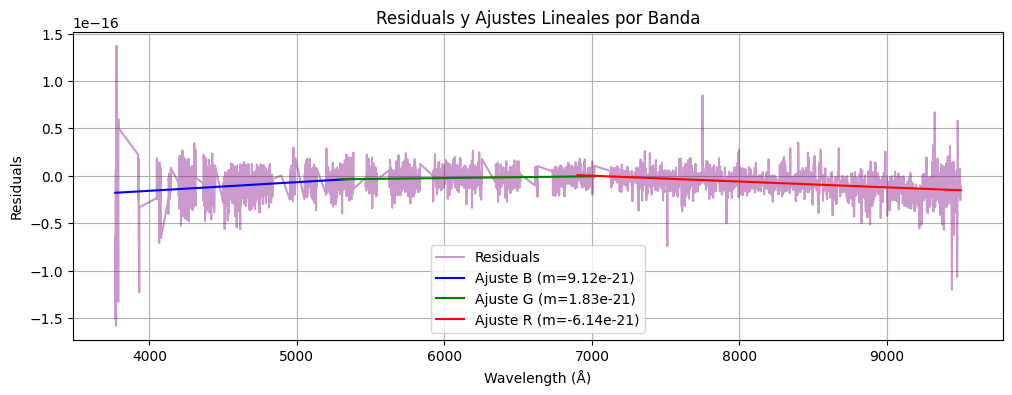

In [89]:
#para caracterizar la slope hacemos un ajuste lineal a los residuals del continuo entero y a las bandas 
n= 0
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, res= residuals(cross_match_2,spect_n_4most)

wave_con= spect_n_4most['wavelength'][mask]

mask_B = (wave_con >= 3700) & (wave_con <= 5400)
mask_G = (wave_con >= 5300) & (wave_con <= 7070)
mask_R = (wave_con >= 6900) & (wave_con <= 9500)

def ajuste_lineal(mask_banda):
    x = wave_con[mask_banda]
    y = residuos[mask_banda]
    
    
    # Ajuste lineal
    m,n = np.polyfit(x,y,1)
    ajuste= (m * x) + n
    return m,x,ajuste

m_B,x_B,ajuste_B= ajuste_lineal(mask_B)
m_G,x_G,ajuste_G= ajuste_lineal(mask_G)
m_R,x_R,ajuste_R= ajuste_lineal(mask_R)


plt.figure(figsize=(12,4))
plt.plot(spect_n_4most['wavelength'][mask], residuos, color='purple', label='Residuals', alpha=0.4)
plt.plot(x_B, ajuste_B, color='blue', label=f'Ajuste B (m={m_B:.2e})')
plt.plot(x_G, ajuste_G, color='green', label=f'Ajuste G (m={m_G:.2e})')
plt.plot(x_R, ajuste_R, color='red', label=f'Ajuste R (m={m_R:.2e})')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Residuals')
plt.title('Residuals y Ajustes Lineales por Banda')
plt.legend()
plt.grid('on')

Match encontrado a 0.15 arcsec de distancia.


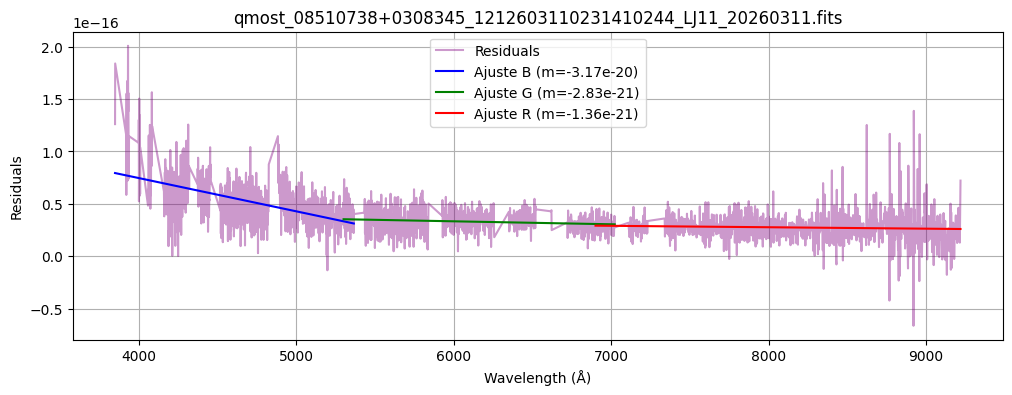

In [110]:
#repetimos para otro espectro 
n= 5
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, res= residuals(cross_match_2,spect_n_4most)

wave_con= spect_n_4most['wavelength'][mask]

mask_B = (wave_con >= 3700) & (wave_con <= 5400)
mask_G = (wave_con >= 5300) & (wave_con <= 7070)
mask_R = (wave_con >= 6900) & (wave_con <= 9500)

m_B,x_B,ajuste_B= ajuste_lineal(mask_B)
m_G,x_G,ajuste_G= ajuste_lineal(mask_G)
m_R,x_R,ajuste_R= ajuste_lineal(mask_R)

plt.figure(figsize=(12,4))
plt.plot(spect_n_4most['wavelength'][mask], residuos, color='purple', label='Residuals', alpha=0.4)
plt.plot(x_B, ajuste_B, color='blue', label=f'Ajuste B (m={m_B:.2e})')
plt.plot(x_G, ajuste_G, color='green', label=f'Ajuste G (m={m_G:.2e})')
plt.plot(x_R, ajuste_R, color='red', label=f'Ajuste R (m={m_R:.2e})')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Residuals')
plt.title(spect_n_4most['filename'] )
plt.legend()
plt.grid('on')

Match encontrado a 2.41 arcsec de distancia.


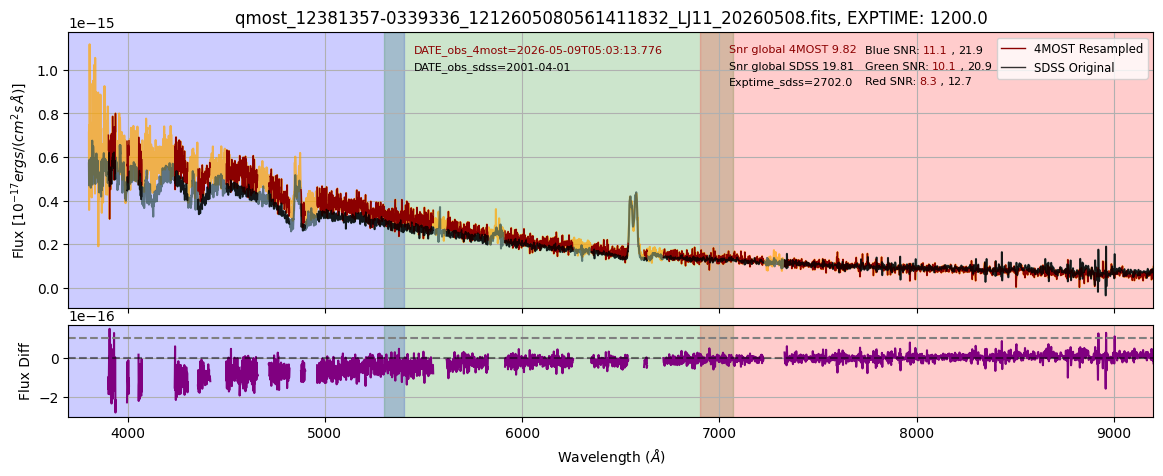

In [91]:
n= 9
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, _= residuals(cross_match_2,spect_n_4most,plot=True)

Match encontrado a 0.55 arcsec de distancia.


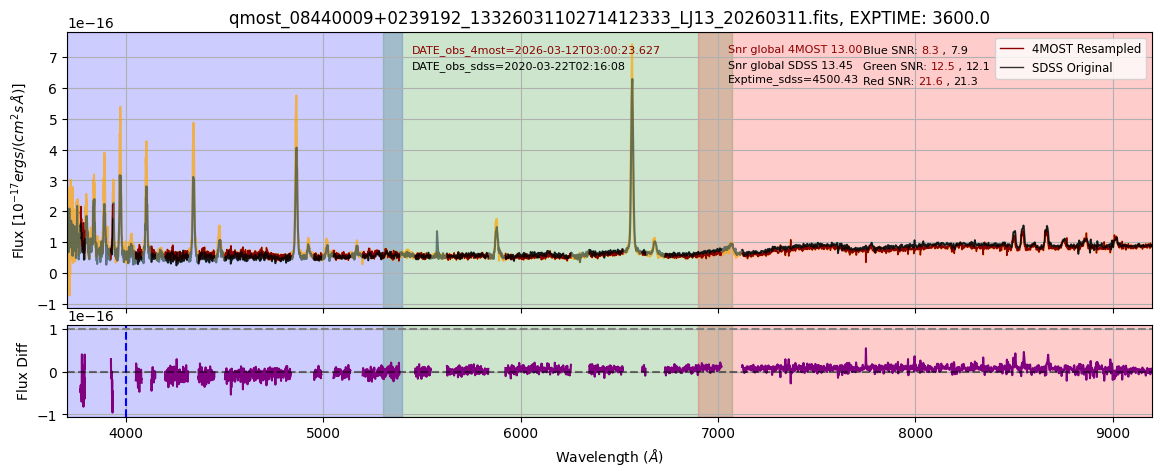

In [115]:
n= 3
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, _= residuals(cross_match_2,spect_n_4most,plot=True)

Match encontrado a 0.55 arcsec de distancia.


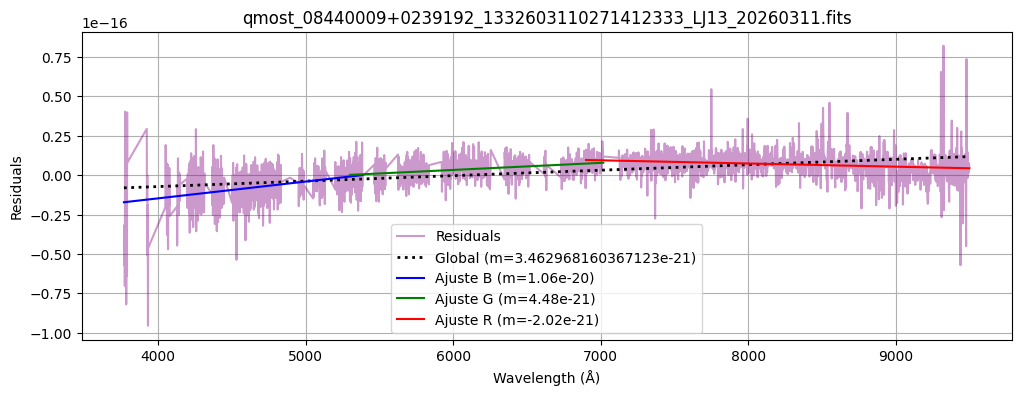

In [114]:
#repetimos para otro espectro 
n= 3
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, res= residuals(cross_match_2,spect_n_4most)

wave_con= spect_n_4most['wavelength'][mask]

mask_B = (wave_con >= 3700) & (wave_con <= 5400)
mask_G = (wave_con >= 5300) & (wave_con <= 7070)
mask_R = (wave_con >= 6900) & (wave_con <= 9500)

m_B,x_B,ajuste_B= ajuste_lineal(mask_B)
m_G,x_G,ajuste_G= ajuste_lineal(mask_G)
m_R,x_R,ajuste_R= ajuste_lineal(mask_R)
m_Global, x_Gl, ajuste_Gl = ajuste_lineal(wave_con > 0) # Todo el espectro

plt.figure(figsize=(12,4))
plt.plot(spect_n_4most['wavelength'][mask], residuos, color='purple', label='Residuals', alpha=0.4)
plt.plot(x_Gl, ajuste_Gl, color='black', linewidth=2, linestyle=':', label=f'Global (m={m_Global})')
plt.plot(x_B, ajuste_B, color='blue', label=f'Ajuste B (m={m_B:.2e})')
plt.plot(x_G, ajuste_G, color='green', label=f'Ajuste G (m={m_G:.2e})')
plt.plot(x_R, ajuste_R, color='red', label=f'Ajuste R (m={m_R:.2e})')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Residuals')
plt.title(spect_n_4most['filename'] )
plt.legend()
plt.grid('on')

In [93]:
#creamos una función para luego procesar tomo en un ciclo 
#la idea es ir guaradando los valores para luego pasarlos a un data frame

datos_tabla=[]

for n in range(len(db_4most)):
    spect_n_4most= db_4most[n]
    cross_match_2=cross_match(spect_n_4most,db_sdss)
    residuos, mask, res= residuals(cross_match_2,spect_n_4most)
    
    obj_name= spect_n_4most['filename'][:20] #dejamos sólo 20 caracteres para ahorrar espacio en la tabla
    date_obs= spect_n_4most['header']['DATE-OBS'][6:] #cortamos el año porque sabemos que es 2026, sólo nos interesa el mes, día y hora
    
    
    wave_con= spect_n_4most['wavelength'][mask]

    mask_B = (wave_con >= 3700) & (wave_con <= 5400)
    mask_G = (wave_con >= 5300) & (wave_con <= 7070)
    mask_R = (wave_con >= 6900) & (wave_con <= 9500)

    def ajuste_lineal(mask_banda):
        x = wave_con[mask_banda]
        y = residuos[mask_banda]
        
        
        # Ajuste lineal
        m,n = np.polyfit(x,y,1)
        ajuste= (m * x) + n
        return m,x,ajuste
    
    m_B,x_B,ajuste_B= ajuste_lineal(mask_B)
    m_G,x_G,ajuste_G= ajuste_lineal(mask_G) 
    m_R,x_R,ajuste_R= ajuste_lineal(mask_R)
    m_Global, x_Gl, ajuste_Gl = ajuste_lineal(wave_con > 0) # Todo el espectro
    

    datos_tabla.append({'objeto': obj_name, 'fecha_obs': date_obs, 'pendiente_B': m_B, 'pendiente_G': m_G, 'pendiente_R': m_R, 'pendiente_Global': m_Global})
    

Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.55 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 0.15 arcsec de distancia.
Match encontrado a 2.41 arcsec de distancia.
Match encontrado a 2.41 arcsec de distancia.
Match encontrado a 2.41 arcsec de distancia.
Match encontrado a 2.41 arcsec de distancia.
Match encontrado a 0.12 arcsec de distancia.
Match encontrado a 0.12 arcsec de distancia.
Match encontrado a 0.12 arcsec de distancia.
Match encontrado a 0.12 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match encontrado a 0.11 arcsec de distancia.
Match enco

Match encontrado a 0.12 arcsec de distancia.


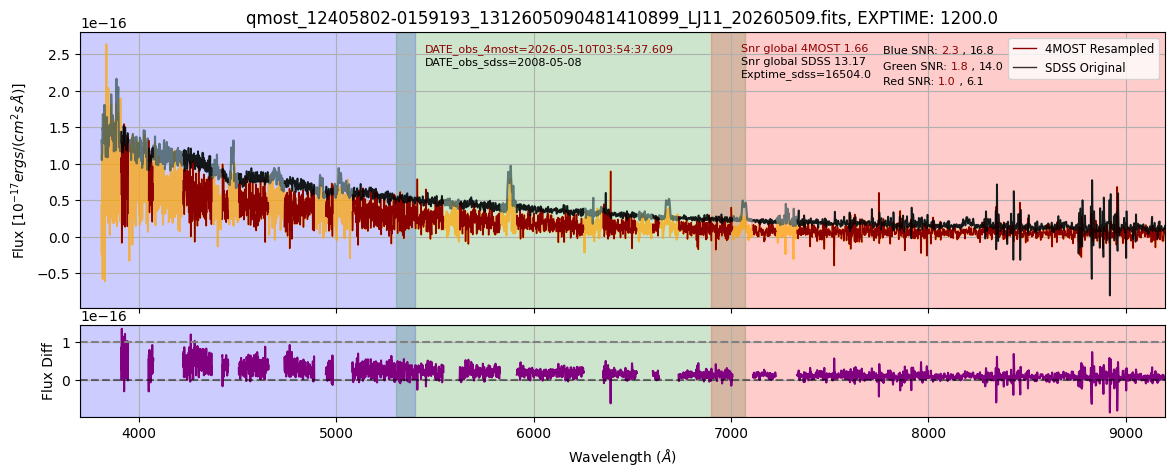

In [ ]:
n= 14
spect_n_4most= db_4most[n]n= 14
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, _= residuals(cross_match_2,spect_n_4most,plot=True)
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, _= residuals(cross_match_2,spect_n_4most,plot=True)

#########################################

Match encontrado a 0.12 arcsec de distancia.


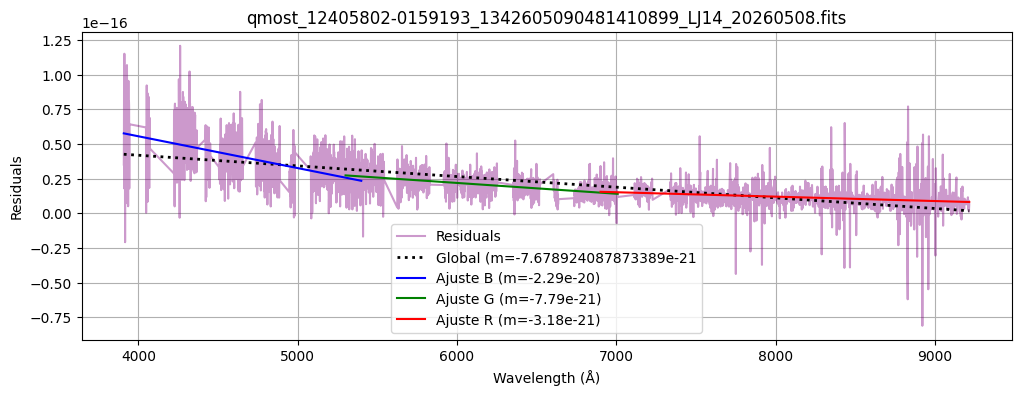

In [95]:
#repetimos para otro espectro 
n= 15
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, res= residuals(cross_match_2,spect_n_4most)

wave_con= spect_n_4most['wavelength'][mask]

mask_B = (wave_con >= 3700) & (wave_con <= 5400)
mask_G = (wave_con >= 5300) & (wave_con <= 7070)
mask_R = (wave_con >= 6900) & (wave_con <= 9500)

m_B,x_B,ajuste_B= ajuste_lineal(mask_B)
m_G,x_G,ajuste_G= ajuste_lineal(mask_G)
m_R,x_R,ajuste_R= ajuste_lineal(mask_R)
m_Global, x_Gl, ajuste_Gl = ajuste_lineal(wave_con > 0) # Todo el espectro

plt.figure(figsize=(12,4))
plt.plot(spect_n_4most['wavelength'][mask], residuos, color='purple', label='Residuals', alpha=0.4)
plt.plot(x_Gl, ajuste_Gl, color='black', linewidth=2, linestyle=':', label=f'Global (m={m_Global}')
plt.plot(x_B, ajuste_B, color='blue', label=f'Ajuste B (m={m_B:.2e})')
plt.plot(x_G, ajuste_G, color='green', label=f'Ajuste G (m={m_G:.2e})')
plt.plot(x_R, ajuste_R, color='red', label=f'Ajuste R (m={m_R:.2e})')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Residuals')
plt.title(spect_n_4most['filename'] )
plt.legend()
plt.grid('on')

In [96]:
df_resultados = pd.DataFrame(datos_tabla)
df_resultados

,objeto,fecha_obs,pendiente_B,pendiente_G,pendiente_R,pendiente_Global
0,qmost_08440009+02391,3-12T02:38:24.910,9.117469e-21,1.833388e-21,-6.135106e-21,-3.405034e-23
1,qmost_08440009+02391,3-12T03:00:23.627,1.597770e-20,6.564044e-21,5.374575e-22,5.867140e-21
2,qmost_08440009+02391,3-12T03:22:22.415,5.756853e-21,4.073969e-21,-1.942549e-21,3.403211e-21
3,qmost_08440009+02391,3-12T03:00:23.627,1.064709e-20,4.481212e-21,-2.021198e-21,3.462968e-21
4,qmost_08510738+03083,3-12T02:38:21.351,-3.403463e-20,-5.686796e-21,-1.945380e-21,-8.564500e-21
5,qmost_08510738+03083,3-12T03:00:20.164,-3.169346e-20,-2.829002e-21,-1.363822e-21,-6.910810e-21
6,qmost_08510738+03083,3-12T03:22:18.965,-3.954317e-20,-7.777203e-21,-2.557428e-21,-1.115902e-20
7,qmost_08510738+03083,3-12T03:00:20.164,-3.469911e-20,-5.091738e-21,-1.748556e-21,-8.600071e-21
8,qmost_12381357-03393,5-09T04:40:33.506,1.302841e-20,-9.767190e-22,3.082531e-22,2.235955e-21
9,qmost_12381357-03393,5-09T05:03:13.776,4.568497e-20,2.051093e-20,8.681827e-21,2.071373e-20


#### figura particular

In [107]:
##### temporal sólo para hacer la figura de manera efectiva
def residualss(spect_n_sdss, spect_n_4most, plot=False):
    """
    Esta función nos devuelve los residuos entre el espectro 1 y el espectro 2 que le damos como input 
    Al primero se le resta el continuo del segundo, i.e., residuos = SDSS - 4MOST. Si usamos el parámetro plot= True podemos ver 
    un gráfico con los residuos y los continuos de cada espectro con las líneas enmascaradas.
    """
    
    #enmascaramos las líneas de ambos espectros 
    sdss_con, sdss_mask, sdss_lines= mask_lines(spect_n_sdss)
    most_con, most_mask, most_lines= mask_lines(spect_n_4most)
    
    #hacemos los continuos globales con las mascaras (con_gaps)
    con_gaps_4most= spect_n_4most['flux'].copy()   #/np.median(spect_n_4most['flux'])
    con_gaps_sdss= spect_n_sdss['flux'].copy()*1E-17     #/np.median(spect_n_sdss['flux'])

    con_gaps_4most[~sdss_mask]=np.nan
    con_gaps_sdss[~sdss_mask]=np.nan
    #Desempaquetamos los espectros originales y la metadata importante (exp_time y magnitudes)
    
    a= spect_n_4most['flux']           #/np.median(spect_n_4most['flux'])
    b= spect_n_sdss['flux']*1E-17            #/np.median(spect_n_sdss['flux'])
    
    header_sdss= spect_n_sdss['header']
    header_4most= spect_n_4most['header']
    
    #mags_4most= [header_4most['OBJ_BL'],header_4most['OBJ_GR'], header_4most['OBJ_RD']]
    #masg_sdss= [header_sdss[],header_sdss[],header_sdss[]]   TENGO PENSIENTE ENCONTRAR LAS MAGNITUDES DE SDSS 
    
    exptime_4most= spect_n_4most['exptime'] 
    exptime_sdss= spect_n_sdss['exptime']
    
    residuos= con_gaps_sdss - con_gaps_4most
    residuoos=  b[sdss_mask] - spect_n_4most['flux'][sdss_mask]
    #calculamos los snr
    snr_4most= [spect_n_4most['snr_r'],spect_n_4most['snr_g'],spect_n_4most['snr_b'],spect_n_4most['snr_global']]
    snr_sdss= [spect_n_sdss['snr_r'],spect_n_sdss['snr_g'],spect_n_sdss['snr_b'],spect_n_sdss['snr_global']]



    if plot:
        plt.figure(figsize=(14,5))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.09)
     
        # panel superior  (espectros)
        ax0 = plt.subplot(gs[0])

        
        ax0.axvspan(3700, 5400, color='blue', alpha=0.2)
        ax0.axvspan(5300, 7070, color='green', alpha=0.2)
        ax0.axvspan(6900, 9500, color='red', alpha=0.2)
        
        
        
        
        # hay que multitplicar el flujo de SDSS por *1E-17 porque viene asumiendo esas unidades
        ax0.plot(spect_n_4most['wavelength'], a, color='orange', alpha= 0.7)
        ax0.plot(spect_n_4most['wavelength'],b, color= 'darkslategrey', alpha= 0.7)
        ax0.plot(spect_n_4most['wavelength'], con_gaps_4most, color='darkred', lw=1, label='4MOST Resampled')
        ax0.plot(spect_n_4most['wavelength'], con_gaps_sdss, color='black', lw=1, alpha=0.8, label='SDSS Original')
        
        y_min, y_max = ax0.get_ylim()

        # Calculamos la posición en las coordenadas de los datos
        # para y usamos y_max bajando un 5% para que no choque con el borde superior

        y_pos = y_max - (y_max - y_min) * 0.05
        ax0.text(7050,y_pos*0.97,f'Snr global 4MOST {snr_4most[-1]:.2f}',color='darkred',fontsize=8)
        ax0.text(7050,y_pos*0.90,f'Snr global SDSS {snr_sdss[-1]:.2f}',fontsize=8)
        ax0.set_xlim(3700,9200)       
        ax0.set_ylabel((r'Flux [$10^{-17} ergs/(cm^2 s\,\AA)$]'))
        ax0.set_title(f"{spect_n_4most.get('filename', 'Objeto')}, EXPTIME: {spect_n_4most.get('exptime')}")
        ax0.legend(loc='upper right', fontsize='small')
        ax0.grid('on')

        # esto es para ocultar la etiqueta del eje X del panel superior para evitar solapamiento
        plt.setp(ax0.get_xticklabels(), visible=False)

        # panel inferior (residuos)
        ax1 = plt.subplot(gs[1], sharex=ax0) # Compartir el eje X es vital
        ax1.axvspan(3700, 5400, color='blue', alpha=0.2)
        ax1.axvspan(5300, 7070, color='green', alpha=0.2)
        ax1.axvspan(6900, 9500, color='red', alpha=0.2)
        
        
        
        #####LINEAS TEMPORALES 
        ax0.axvline(4000,color= 'blue', linestyle='dashed')
        ax0.axvline(4500,color= 'blue', linestyle='dashed')
        ax0.axvline(6513,color= 'green', linestyle='dashed')
        ax0.axvline(6613,color= 'green', linestyle='dashed')
        ax0.axvline(8350,color= 'red', linestyle='dashed')
        ax0.axvline(8850,color= 'red', linestyle='dashed')
        
        ax1.plot(spect_n_4most['wavelength'], residuos, color='purple', label='Residuals (SDSS - 4MOST)')
        ax1.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea de referencia en cero
        
        #ax1.axhline(1*1E-16,color='grey', linestyle='--') # Línea de referencia en 1 (si los residuos son del orden del ruido)
        
        ax1.set_xlabel(r'Wavelength ($\AA$)')
        ax1.set_ylabel('Flux Diff')
        ax1.grid('on')
        #ax1.set_ylim(-0.5, 0.5) # depende de la escala de los residuos 
        ax1.set_xlim(3700,9200)
        #plt.tight_layout()

        
        
        texto_snr = (
            f"Blue SNR: <{snr_4most[2]:.1f}> , <{snr_sdss[2]:.1f}> \n"
            f"Green SNR: <{snr_4most[1]:.1f}> , <{snr_sdss[1]:.1f}> \n"
            f"Red SNR: <{snr_4most[0]:.1f}> , <{snr_sdss[0]:.1f}> "
        )
        
        
        
        #TEXTO CON LA HORA DE OBSERVACIÓN 
        ax0.text(5450,y_pos*0.97,f'DATE_obs_4most={header_4most['DATE-OBS']}',color='darkred',fontsize=8)
        ax0.text(5450,y_pos*0.90,f'DATE_obs_sdss={spect_n_sdss['date_obs']}',color='black',fontsize=8)
        
        ax0.text(7050,y_pos*0.84,f'Exptime_sdss={exptime_sdss}',fontsize=8)
        #texto_mag= (f"Blue mag:<{mags_4most[0]:.1f}> \n"
        #            f"Green mag:<{mags_4most[1]:.1f}> \n"
        #            f"Red mag:<{mags_4most[2]:.1f}> " )
        
        #ax_text(7700,y_pos, texto_mag, transform=ax0.transAxes, 
        #        fontsize=8, ha='right', va='top',
        #        highlight_textprops=[
        #            {"color": "darkred"}, 
        #            {"color": "darkred"},
        #            {"color": "darkred"},
        #        ],
        #        ax=ax0)

        # ax_text inyecta el texto y colorea lo que está entre <>
        ax_text(8400, y_pos, texto_snr, transform=ax0.transAxes, 
                fontsize=8, ha='right', va='top',
                highlight_textprops=[
                    {"color": "darkred"}, {"color": "black"},
                    {"color": "darkred"}, {"color": "black"},
                    {"color": "darkred"}, {"color": "black"}
                ],
                ax=ax0)
        plt.show()
    
    return residuoos, sdss_mask, residuos

Match encontrado a 0.09 arcsec de distancia.


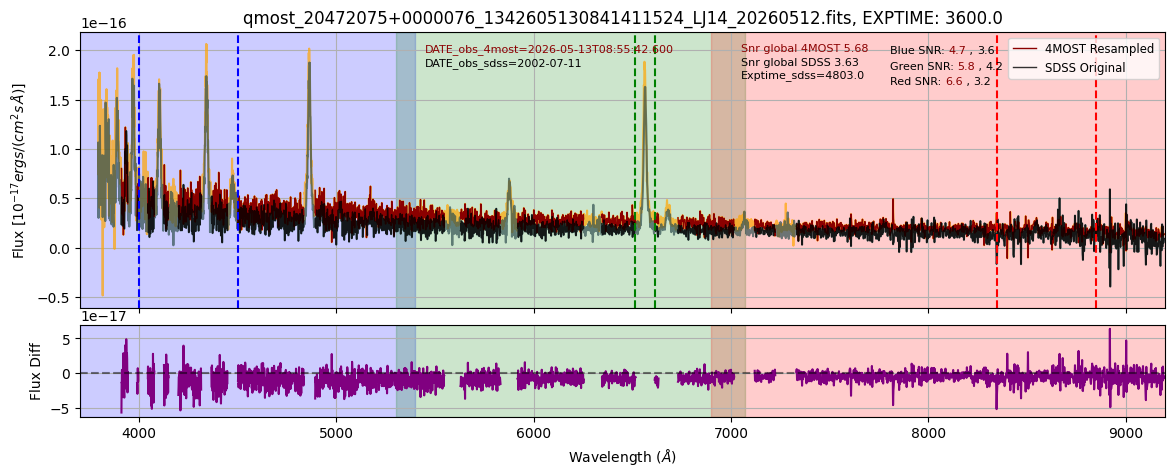

In [108]:
n= 36
spect_n_4most= db_4most[n]
cross_match_2=cross_match(spect_n_4most,db_sdss)
residuos, mask, _= residualss(cross_match_2,spect_n_4most,plot=True)